# Brain Tumor Classification

With dataset merge step (training + testing) before preprocessing. Hence,

`Acquire -> Merge data from folders (Train & Test) -> train_test_split() merged data -> Preprocess -> Extract -> Classify -> Evaluate -> XAI`

## Preparation

### System Check

In [1]:
# Software check (OS)
!uname -a

# Hardware check (CPU, GPU, RAM)
!inxi

Linux xt 6.17.0-20-generic #20~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Thu Mar 19 01:28:37 UTC 2 x86_64 x86_64 x86_64 GNU/Linux


CPU: 6-core AMD Ryzen 5 7640HS w/ Radeon 760M Graphics (-MT MCP-)
speed/min/max: 2663/410/5018 MHz Kernel: 6.17.0-20-generic x86_64 Up: 1m
Mem: 4.39/14.81 GiB (29.7%) Storage: 1.38 TiB (3.0% used) Procs: 412
Shell: python inxi: 3.3.34


### Library Imports


In [2]:
# System
import os
from glob import glob
from zipfile import ZipFile
import pickle

# Utilities
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import time

# Data Preparation & Hyperparameter Tuning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# LBP Library
from skimage.feature import local_binary_pattern

# Classical Machine Learning Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import LinearSVC
from sklearn.svm import SVC

# Deep Learning CNN Model
import keras
from keras import layers
from keras.callbacks import EarlyStopping

# Evaluation Functions
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# LIME XAI
from lime import lime_image
from skimage.segmentation import mark_boundaries

2026-04-20 10:43:11.605237: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-20 10:43:11.618232: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-20 10:43:12.093520: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-20 10:43:13.724542: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

### Global Variable(s)

In [3]:
# Image size for resize process of preprocessing step
IMAGE_SIZE = 128
CNN_IMAGE_SIZE = 128

# List of utilized feature extraction methods and their parameters
FEATURES = ["lbp-lib", "lbp", 
            "nlbp1", "nlbp2", "nlbp3", "nlbp4", 
            "albp0", "albp45", "albp90", "albp135", 
            "mblbp2", "mblbp3", "mblbp4", 
            "semblbp2", "semblbp3", "semblbp4"]

## Dataset Acquisition


### File Extraction

In [4]:
dataset_path = "./data/"
dataset_file = dataset_path + "brain-sartaj.zip"

# Extract zipped dataset file
zipfile = ZipFile(dataset_file)
zipfile.extractall(dataset_path)
zipfile.close()

print("Dataset File & Folders:", os.listdir(dataset_path))

Dataset File & Folders: ['Training', 'Testing', 'brain-sartaj.zip']


In [5]:
train_path = os.path.join(dataset_path, "Training")
test_path = os.path.join(dataset_path, "Testing")

# List of dataset classes/labels
classes = os.listdir(train_path)

print("Dataset Classes:", classes)

Dataset Classes: ['meningioma_tumor', 'glioma_tumor', 'pituitary_tumor', 'no_tumor']


### Train & Test Merge

In [6]:
# Data and labels from merged Training and Testing folders
X, y = [], []

for idx, label in enumerate(classes):
    # Input Training folder image data and labels to merged lists
    train_images = glob(os.path.join(train_path, label, "*.jpg"))
    for img_raw in train_images:
        img = cv.imread(img_raw)
        X.append(img)
        y.append(idx)
    
    # Input Testing folder image data and labels to merged lists
    test_images = glob(os.path.join(test_path, label, "*.jpg"))
    for img_raw in test_images:
        img = cv.imread(img_raw)
        X.append(img)
        y.append(idx)

print("X\ty")
print(f"{len(X)}\t{len(y)}")

X	y
3264	3264


### Train & Test Split

In [ ]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,  # 80:20 Train:Test Ratio
    random_state=42,
    stratify=y,
)

print("X_train\ty_train\t")
print(f"{len(X_train)}\t{len(y_train)}\n")
print("X_test\ty_test\t")
print(f"{len(X_test)}\t{len(y_test)}\t")

X_train	y_train	
2611	2611

X_test	y_test	
653	653	


## Classical Machine Learning

### ML - Preprocessing

In [8]:
# Data preprocessing function for machine learning classifiers
def preprocess_ml(images):
    preprocessed = []

    for img in images:
        # Resize image into same resolutions
        img_resized = cv.resize(img, (IMAGE_SIZE, IMAGE_SIZE))

        # Convert image from BGR (3-channels) to grayscale (1-channel)
        img_grayscaled = cv.cvtColor(img_resized, cv.COLOR_BGR2GRAY)
        
        preprocessed.append(img_grayscaled)
    
    return preprocessed

In [9]:
# Preprocess dataset for machine learning classifier feature extractions
X_train_prep = preprocess_ml(X_train)
X_test_prep = preprocess_ml(X_test)

print("X_train_prep\ty_train")
print(f"{len(X_train_prep)}\t\t{len(y_train)}\n")
print("X_test_prep\ty_test")
print(f"{len(X_test_prep)}\t\t{len(y_test)}")

X_train_prep	y_train
2611		2611

X_test_prep	y_test
653		653


#### Preprocessed Dataset Preview

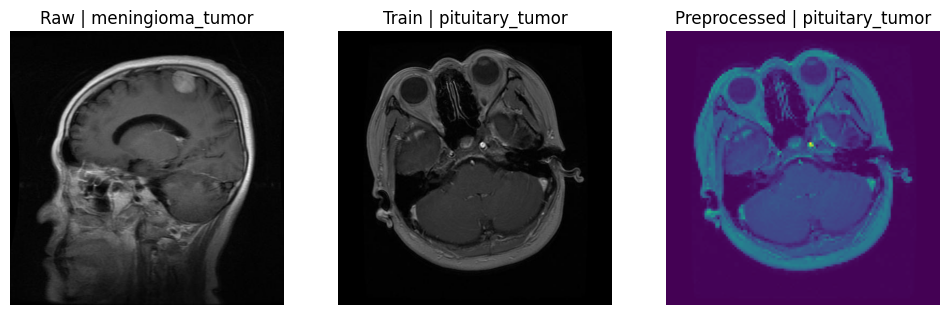

In [10]:
prvw_idx = 42
plt.figure(figsize=(12,4))

# Raw (merged) dataset sample
plt.subplot(1, 3, 1)
plt.title(f"Raw | {classes[y[prvw_idx]]}")
plt.axis('off')
plt.imshow(X[prvw_idx])

# Train dataset sample
plt.subplot(1, 3, 2)
plt.title(f"Train | {classes[y_train[prvw_idx]]}")
plt.axis('off')
plt.imshow(X_train[prvw_idx])

# Preprocessed train dataset sample
plt.subplot(1,3,3)
plt.title(f"Preprocessed | {classes[y_train[prvw_idx]]}")
plt.axis('off')
plt.imshow(X_train_prep[prvw_idx])

plt.show()

### ML - Feature Extraction

In [11]:
# Convert binary list value to decimal representation
def get_decimal(binary, uniform=True):
    transition = 0
    decimal = 0

    # Assign each binary digit to its decimal weight
    for i in range(8):
        # Count transitions by comparing current bit with the next bit
        next_bit = (i+1) % 8
        # Add the transition count if those two bit values are different
        transition += binary[i] != binary[next_bit]
        # Convert every bit of a binary list into its decimal value
        decimal = decimal * 2 + binary[i]

    # Uniform pattern filtering for classical LBP
    if(uniform): return decimal if(transition <= 2) else 256

    return decimal

# Get histogram representation of image feature
def get_histogram(img, non_uniform=0, library=False):
    histogram, _ = np.histogram(a=img, bins=[x for x in range(257)])
    uniform_histogram = []

    # LBP with non-uniform histogram simplification
    if(non_uniform > 0):
        # Delete zero values throughout the list
        uniform_histogram = np.delete(histogram, np.where(histogram == 0))
        # Append non uniform value into 59th element of the uniform pattern histogram 
        uniform_histogram = np.append(uniform_histogram, non_uniform)
        return uniform_histogram
    
    # LBP histogram simplification from built-in sklearn library
    if(library):
        # Delete zero values from histogram
        histogram = np.delete(histogram, np.where(histogram == 0))

    return histogram

In [12]:
# Neighboring pixels' coordinates of the center pixel
P_COORDS = [(-1, -1), (-1, 0), (-1, 1), # (top left) (top center) (top right)
            ( 0,  1),                   # (center right)
            ( 1,  1), ( 1, 0), (1, -1), # (bottom right) (bottom center) (bottom left)
            ( 0, -1)]                   # (center left)

#### Classic LBP

In [ ]:
def get_lbp(img, uniform=True):
    height, width = img.shape
    # Add padding to image edges with the value of 0
    img_pad = np.pad(img, pad_width=1, mode="constant", constant_values=0)
    img_lbp = np.zeros((height, width), np.uint8)
    non_uniform = 0

    for i in range(height):
        for j in range(width):
            # Center pixel on padded image
            c_i, c_j = i+1, j+1
            c = img_pad[c_i, c_j]

            # Center pixel's binary representation
            c_bin = []

            for p_coord in P_COORDS:
                # Neighboring pixels of center pixel
                p = img_pad[c_i + p_coord[0], c_j + p_coord[1]]

                # Threshold and append bit value to pixel representation
                c_bin.append(1 if(p > c) else 0)

            # Convert center pixel's binary representation to its decimal value
            decimal = get_decimal(c_bin, uniform=uniform)
            # Filter non-uniform pattern
            if(decimal == 256): non_uniform += 1
            # Assign uniform decimal value
            else: img_lbp[i][j] = decimal

    # Get relevant feature vector histogram based on the created feature image
    hist_lbp = get_histogram(img_lbp, non_uniform)

    return img_lbp, hist_lbp

#### nLBP


In [ ]:
def get_nlbp(img, distance):
    height, width = img.shape
    img_pad = np.pad(img, pad_width=1, mode="constant", constant_values=0)
    img_nlbp = np.zeros((height, width), np.uint8)

    for i in range(height):
        for j in range(width):
            # Center pixel's coordinates on padded image
            c_i, c_j = i+1, j+1

            c_bin = []

            for p in range(8):
                # First neighboring pixel to compare
                p_a = img_pad[c_i + P_COORDS[p][0], c_j + P_COORDS[p][1]]
                
                # Second neighboring pixel to compare
                p_b_idx = (p+distance) % 8
                p_b = img_pad[c_i + P_COORDS[p_b_idx][0], c_j + P_COORDS[p_b_idx][1]]

                # Compare first with second neighboring pixels
                # Append bit value to pixel's binary representation
                c_bin.append(1 if(p_a > p_b) else 0)

            # Convert & assign every center pixel's binary representations to its decimal values
            decimal = get_decimal(c_bin, uniform=False)
            img_nlbp[i][j] = decimal

    hist_nlbp = get_histogram(img_nlbp)

    return img_nlbp, hist_nlbp

#### αLBP


In [ ]:
def get_albp(img, alpha, neighbors=4):
    height, width = img.shape
    # Add image paddings as much as half of the neighboring pixels
    img_pad = np.pad(img, pad_width=neighbors, mode="constant", constant_values=0)
    img_albp = np.zeros((height, width), np.uint8)

    # Neighboring pixels' coordinate candidates based on the chosen alpha parameter
    p_coords_list = {
        0  : [( 0, 4), ( 0, 3), ( 0, 2), ( 0, 1), ( 0,-1), ( 0,-2), ( 0,-3), ( 0,-4)],
        45 : [(-4, 4), (-3, 3), (-2, 2), (-1, 1), ( 1,-1), ( 2,-2), ( 3,-3), ( 4,-4)],
        90 : [(-4, 0), (-3, 0), (-2, 0), (-1, 0), ( 1, 0), ( 2, 0), ( 3, 0), ( 4, 0)],
        135: [(-4,-4), (-3,-3), (-2,-2), (-1,-1), ( 1, 1), ( 2, 2), ( 3, 3), ( 4, 4)],
    }

    # Handle alpha parameter input outside the scope
    if(alpha % 360 not in p_coords_list.keys()):
        return print("Incorrect alpha parameter value")

    for i in range(height):
        for j in range(width):
            # Center pixel on padded image
            c_i, c_j = i+neighbors, j+neighbors
            c = img_pad[c_i][c_j]
            
            # Chosen neighboring pixels from alpha parameter
            p_coords = p_coords_list[alpha]

            c_bin = []

            for p in p_coords:
                # Coordinates of the neighboring pixels based on their center
                p_i_crd = c_i + p[0] # Y plane
                p_j_crd = c_j + p[1] # X plane
                
                # Neighboring pixel to be compared with the center pixel 
                p = img_pad[p_i_crd, p_j_crd]

                # Compare center pixel with current neighboring pixel
                # Append bit value to pixel's binary representation
                c_bin.append(1 if p > c else 0)

            decimal = get_decimal(c_bin, uniform=False)
            img_albp[i][j] = decimal

    hist_albp = get_histogram(img_albp)

    return img_albp, hist_albp

#### MB-LBP (and SEMB-LBP)

In [26]:
def get_integral_image(img):
    height, width = img.shape
    
    img_integral = np.zeros((height, width), int)
    img_integral_pad = np.pad(img_integral, pad_width=1, mode="constant", constant_values=0)
    
    for i in range(height):
        for j in range(width):
            # Get the current pixel's integral image value 
            # by adding its pixel intensity value with its above and left side of integral image value
            # then substract overlapping values from the top-left side 
            img_integral_pad[i][j] = img[i][j] + img_integral_pad[i-1][j] + img_integral_pad[i][j-1] - img_integral_pad[i-1][j-1]

    # Return image integral result with removed zero paddings
    return img_integral_pad[:-2,:-2]

def get_mblbp(img, region_size, v=0):
    height, width = img.shape

    # Rounded (ceiling division) size values from base image to get the region image size
    region_height = -(-height // region_size)
    region_width = -(-width // region_size)

    img_integral = get_integral_image(img)
    img_region = np.zeros((region_height, region_width), int)
    img_pad = np.pad(img_integral, pad_width=region_size, mode="constant", constant_values=0)

    for i in range(region_height):
        for j in range(region_width):
            # Integral image variables
            # Top-Left
            a = img_pad[i*region_size-1, j*region_size-1] if(i*region_size-1>0 and j*region_size-1>0) else 0
            # Top-Right
            b = img_pad[i*region_size-1, j*region_size+region_size-1] if(i*region_size-1>0 and j*region_size+region_size-1>0) else 0
            # Bottom-Left
            c = img_pad[i*region_size+region_size-1, j*region_size-1] if(i*region_size+region_size-1>0 and j*region_size-1>0) else 0
            # Bottom-Right
            d = img_pad[i*region_size+region_size-1, j*region_size+region_size-1]
            
            # Region's sum and mean value using integral image formula
            region_sum = d - b - c + a
            img_region[i][j] = region_sum / (region_size*region_size)

    # MB-LBP image feature
    img_mblbp, hist_mblbp = get_lbp(img_region, uniform=False)

    # Override histogram for SEMB-LBP 
    # v parameter to set the values of less frequent features
    if(v > 0): hist_mblbp = get_semblbp_histogram(img_mblbp, v)

    return img_mblbp, hist_mblbp

def get_semblbp_histogram(img, v=63):
    # Top n features to preserve its values
    n = 63
    # Image region histogram from MB-LBP features
    semb_hist = get_histogram(img)
    # Descendingly sorted indices of mostly appeared features in image histogram
    semb_sorted_idx = np.argsort(semb_hist)[::-1]
    # SEMB-LBP image features
    # Keep the n mostly appeared feature values,
    # Set the rest (>=n+1)th mostly appeared values to v 
    semb_sorted = np.array([(semb_hist[i]) if i in semb_sorted_idx[:n] else v for i in range(256)])

    return semb_sorted

#### Feature Extraction Process

In [ ]:
# Feature extraction process for each methods
def get_feature_histogram(image, method, param=None, v=None):
    match method:
        # Local binary pattern using library from scikit-learn
        case "lbp-lib":
            feat = local_binary_pattern(image, P=8, R=1, method="nri_uniform")
            hist = get_histogram(feat, library=True)
        # Local binary pattern from scratch
        case "lbp":
            feat, hist = get_lbp(image)
        case "nlbp":
            feat, hist = get_nlbp(image, param)
        case "albp":
            feat, hist = get_albp(image, param)
        case "mblbp":
            feat, hist = get_mblbp(image, param)
        # SEMB-LBP
        case _:
            feat, hist = get_mblbp(image, param, v)

    return feat, hist

# Feature extraction function for train and test set
def get_features(images, method, param=None, v=None):
    print(f"{len(images)} images > Method: {method}\tParam: {param}\t", end="")
    
    start_feature_extractions = time.perf_counter()
    
    # Created image features and histograms of all image set
    features, histograms = [], []

    for image in images:
        # Each image's extracted image feature & histograms
        img_feature, img_histogram = get_feature_histogram(image, method, param, v)

        features.append(img_feature)
        histograms.append(img_histogram)
        
    print(f"> Completed in {time.perf_counter() - start_feature_extractions}s.")

    return features, histograms

In [18]:
print("Extracting Features: Train Set\n")

train_fe_time_start = time.perf_counter()

X_train_lbplib, X_train_lbplib_hist = get_features(X_train_prep, "lbp-lib")        
X_train_lbp, X_train_lbp_hist = get_features(X_train_prep, "lbp")                  

X_train_nlbp1, X_train_nlbp1_hist = get_features(X_train_prep, "nlbp", 1)          
X_train_nlbp2, X_train_nlbp2_hist = get_features(X_train_prep, "nlbp", 2)          
X_train_nlbp3, X_train_nlbp3_hist = get_features(X_train_prep, "nlbp", 3)          
X_train_nlbp4, X_train_nlbp4_hist = get_features(X_train_prep, "nlbp", 4)          

X_train_albp0, X_train_albp0_hist = get_features(X_train_prep, "albp", 0)          
X_train_albp45, X_train_albp45_hist = get_features(X_train_prep, "albp", 45)       
X_train_albp90, X_train_albp90_hist = get_features(X_train_prep, "albp", 90)       
X_train_albp135, X_train_albp135_hist = get_features(X_train_prep, "albp", 135)    

X_train_mblbp2, X_train_mblbp2_hist = get_features(X_train_prep, "mblbp", 2)       
X_train_mblbp3, X_train_mblbp3_hist = get_features(X_train_prep, "mblbp", 3)       
X_train_mblbp4, X_train_mblbp4_hist = get_features(X_train_prep, "mblbp", 4)       

X_train_semblbp2, X_train_semblbp2_hist = get_features(X_train_prep, "semb", 2, 63)
X_train_semblbp3, X_train_semblbp3_hist = get_features(X_train_prep, "semb", 3, 31)
X_train_semblbp4, X_train_semblbp4_hist = get_features(X_train_prep, "semb", 4, 15)

print(f"\nAll Features Extracted in {time.perf_counter() - train_fe_time_start}s")

Extracting Features: Training Data

2611 images > Method: lbp-lib	Param: None	> Completed in 5.997831168999994s.
2611 images > Method: lbp	Param: None	> Completed in 72.59199610099998s.
2611 images > Method: nlbp	Param: 1	> Completed in 108.06870154999999s.
2611 images > Method: nlbp	Param: 2	> Completed in 107.63392287900001s.
2611 images > Method: nlbp	Param: 3	> Completed in 107.787825166s.
2611 images > Method: nlbp	Param: 4	> Completed in 107.58584258099995s.
2611 images > Method: albp	Param: 0	> Completed in 75.31765162299996s.
2611 images > Method: albp	Param: 45	> Completed in 75.60043126599999s.
2611 images > Method: albp	Param: 90	> Completed in 75.559173998s.
2611 images > Method: albp	Param: 135	> Completed in 75.59923977099993s.
2611 images > Method: mblbp	Param: 2	> Completed in 56.47217075200001s.
2611 images > Method: mblbp	Param: 3	> Completed in 42.141238147000195s.
2611 images > Method: mblbp	Param: 4	> Completed in 36.95018809099997s.
2611 images > Method: semb	Para

In [ ]:
# Store extracted image features to reduce redundancy
X_train_feats = [X_train_lbplib, X_train_lbp,
                 X_train_nlbp1, X_train_nlbp2, X_train_nlbp3, X_train_nlbp4,
                 X_train_albp0, X_train_albp45, X_train_albp90, X_train_albp135, 
                 X_train_mblbp2, X_train_mblbp3, X_train_mblbp4,
                 X_train_semblbp2, X_train_semblbp3, X_train_semblbp4]

# Store extracted histograms to reduce redundancy
X_train_hists = [X_train_lbplib_hist, X_train_lbp_hist,
                 X_train_nlbp1_hist, X_train_nlbp2_hist, X_train_nlbp3_hist, X_train_nlbp4_hist, 
                 X_train_albp0_hist, X_train_albp45_hist, X_train_albp90_hist, X_train_albp135_hist, 
                 X_train_mblbp2_hist, X_train_mblbp3_hist, X_train_mblbp4_hist,
                 X_train_semblbp2_hist, X_train_semblbp3_hist, X_train_semblbp4_hist]

#### Feature Extraction Data

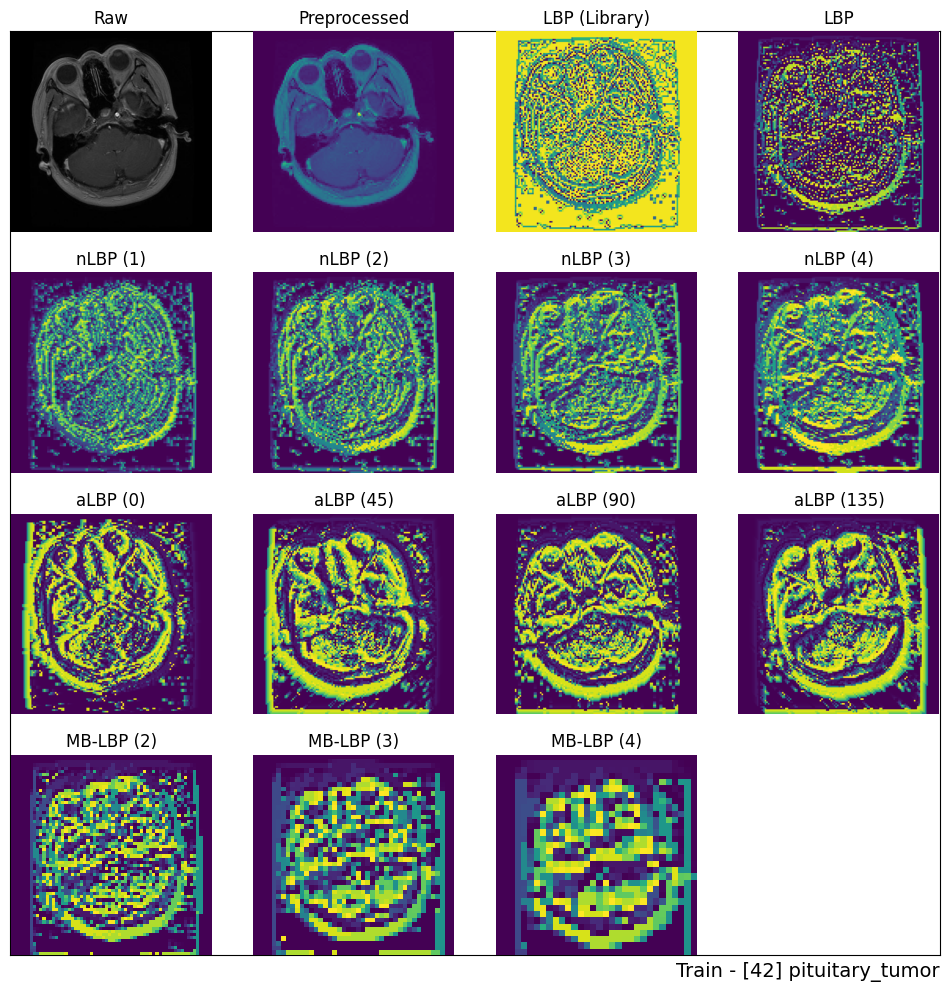

In [20]:
prvw_idx = 42

plt.figure(figsize=(12,12))
plt.xlabel(f"Train - [{prvw_idx}] {classes[y_train[prvw_idx]]}", fontsize=14, loc="right")
plt.yticks([])
plt.xticks([])

def get_image_preview(title, data, idx):
    plt.subplot(4, 4, idx)
    plt.axis("off")
    plt.title(f"{title}")
    plt.imshow(data[prvw_idx])

get_image_preview("Raw", X_train, 1)
get_image_preview("Preprocessed", X_train_prep, 2)
get_image_preview("LBP (Library)", X_train_lbplib, 3)
get_image_preview("LBP", X_train_lbp, 4)
get_image_preview("nLBP (1)", X_train_nlbp1, 5)
get_image_preview("nLBP (2)", X_train_nlbp2, 6)
get_image_preview("nLBP (3)", X_train_nlbp3, 7)
get_image_preview("nLBP (4)", X_train_nlbp4, 8)
get_image_preview("aLBP (0)", X_train_albp0, 9)
get_image_preview("aLBP (45)", X_train_albp45, 10)
get_image_preview("aLBP (90)", X_train_albp90, 11)
get_image_preview("aLBP (135)", X_train_albp135, 12)
get_image_preview("MB-LBP (2)", X_train_mblbp2, 13)
get_image_preview("MB-LBP (3)", X_train_mblbp3, 14)
get_image_preview("MB-LBP (4)", X_train_mblbp4, 15)
# get_image("SEMB-LBP (2)", X_train_semblbp2, 17)
# get_image("SEMB-LBP (3)", X_train_semblbp3, 18)
# get_image("SEMB-LBP (4)", X_train_semblbp4, 19)

plt.show()

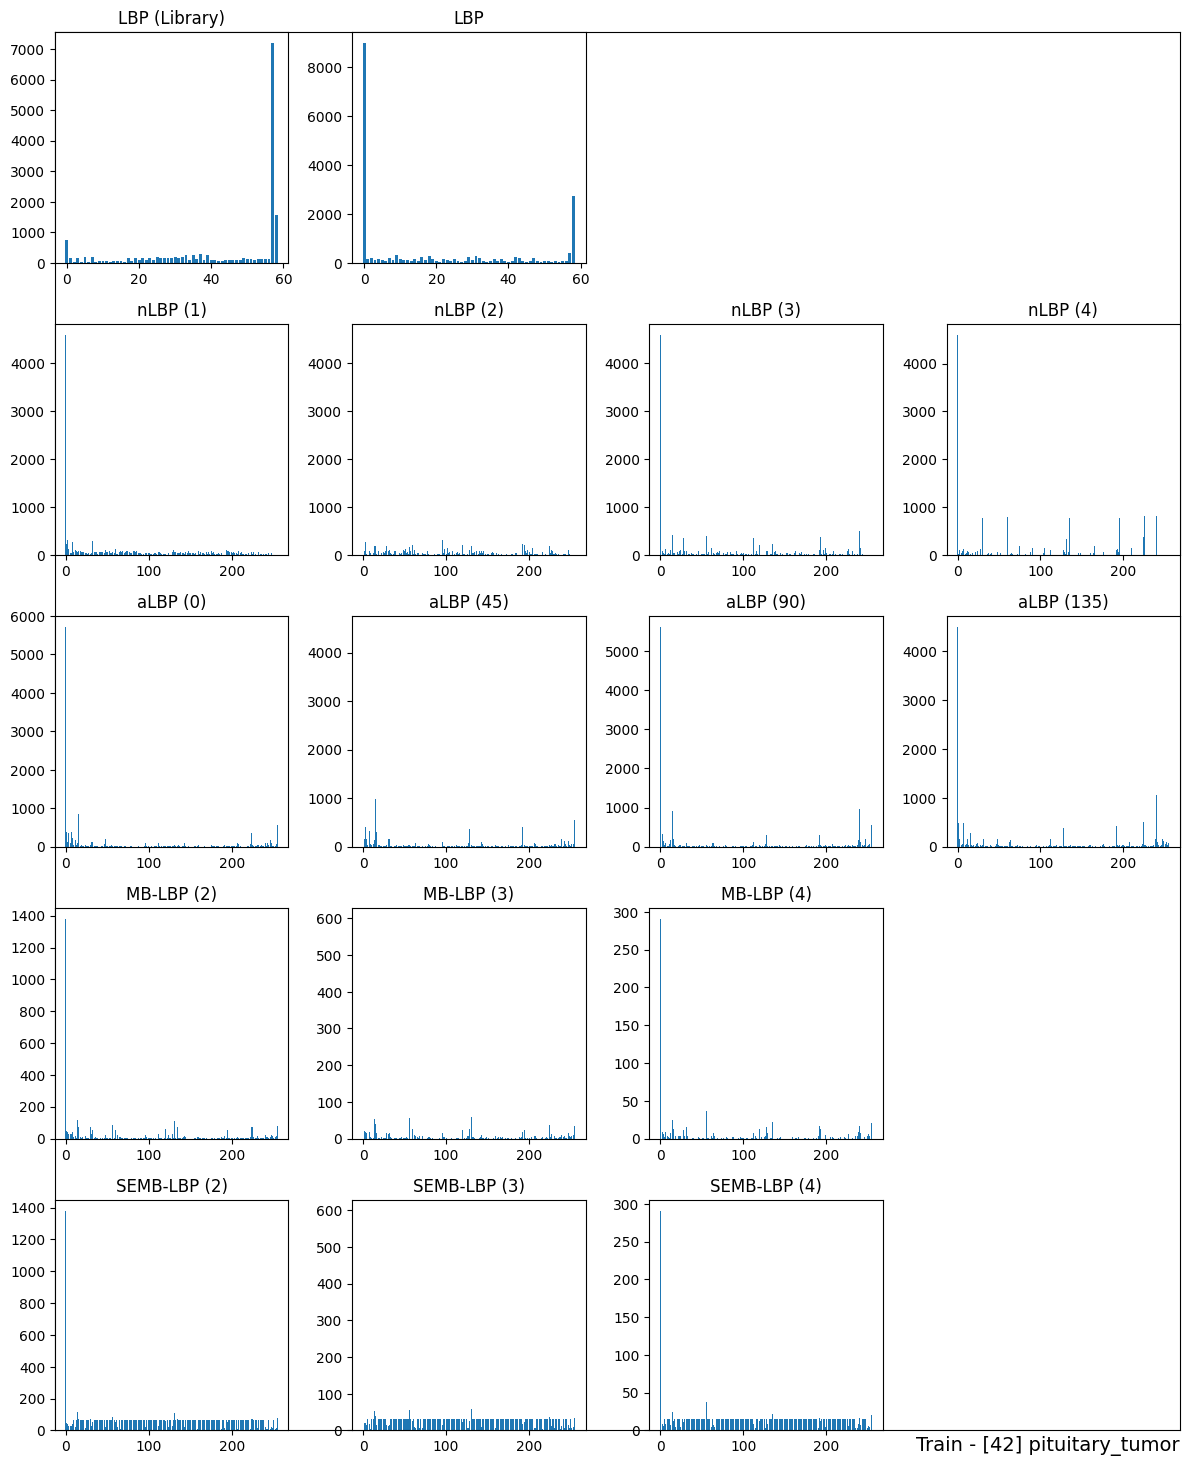

In [21]:
plt.figure(figsize=(12,15))
plt.xlabel(f"Train - [{prvw_idx}] {classes[y_train[prvw_idx]]}", fontsize=14, loc="right")
plt.yticks([])
plt.xticks([])

def get_histogram_preview(title, data, idx):
    plt.subplot(5, 4, idx)
    plt.title(f"{title}")
    plt.tight_layout()
    plt.bar(np.arange(len(data[prvw_idx])), data[prvw_idx])

# get_histogram_preview("Raw", X_train, 1)
# get_histogram_preview("Preprocessed", X_train_prep, 2)
get_histogram_preview("LBP (Library)", X_train_lbplib_hist, 1)
get_histogram_preview("LBP", X_train_lbp_hist, 2)
get_histogram_preview("nLBP (1)", X_train_nlbp1_hist, 5)
get_histogram_preview("nLBP (2)", X_train_nlbp2_hist, 6)
get_histogram_preview("nLBP (3)", X_train_nlbp3_hist, 7)
get_histogram_preview("nLBP (4)", X_train_nlbp4_hist, 8)
get_histogram_preview("aLBP (0)", X_train_albp0_hist, 9)
get_histogram_preview("aLBP (45)", X_train_albp45_hist, 10)
get_histogram_preview("aLBP (90)", X_train_albp90_hist, 11)
get_histogram_preview("aLBP (135)", X_train_albp135_hist, 12)
get_histogram_preview("MB-LBP (2)", X_train_mblbp2_hist, 13)
get_histogram_preview("MB-LBP (3)", X_train_mblbp3_hist, 14)
get_histogram_preview("MB-LBP (4)", X_train_mblbp4_hist, 15)
get_histogram_preview("SEMB-LBP (2)", X_train_semblbp2_hist, 17)
get_histogram_preview("SEMB-LBP (3)", X_train_semblbp3_hist, 18)
get_histogram_preview("SEMB-LBP (4)", X_train_semblbp4_hist, 19)

plt.show()

### ML - Classification

In [ ]:
# Machine learning model cross validation and training function
def get_model(i, method, base_model, param_grid, X_train_model, scale=False):
    print(f"{str(i).ljust(2)} {method}".ljust(8), end="\t")

    # Begin modelling time counting
    start = time.perf_counter()

    # Sequence of feature vectors processing
    pipe = Pipeline([
        # Scale the feature vectors
        ("scaler", StandardScaler()) if scale else ("none", None),
        ("classifier", base_model),
    ])

    # Model cross validating and hyperparameter tuning
    classifier = GridSearchCV(estimator=pipe,
                              param_grid=param_grid,
                              scoring="f1_macro",   # Handle imbalanced dataset with same weights of classes
                              n_jobs=-1,            # Utilize all available processors
                              cv=5,
                              verbose=0)
    # Train & fit model with extracted features and labels
    classifier.fit(X_train_model, y_train)

    modelling_time = time.perf_counter() - start

    print(f"{round(classifier.best_score_, 6)}".ljust(8),
          f"{round(modelling_time, 6)}s".ljust(10),
          f"{classifier.best_params_}",
          sep="\t")
    
    # Store model performance result in a map for better accessibility
    result = {
        "method": method, 
        "model": classifier, 
        "time": modelling_time
    }

    return result

# Machine learning bulk modelling function for all feature extraction methods
def get_models(title, base_model, param_grid, X_train_model, scale=False, best=False):
    ml_models = []
    
    print(f">  {title}\n")
    print("   Method", "Score", "\tTime", "\tParameters", sep="\t")

    for i, feature in enumerate(FEATURES):
        # Train and store models with each features
        model = get_model(i, feature, base_model, param_grid, X_train_model[i], scale)
        ml_models.append(model)

    return ml_models

def get_best_models(models, model_title):
    # Sort models descendingly based on their cross validation evaluation (f1_macro) scores
    sorted_models = sorted(models, key=lambda x:x["model"].best_score_, reverse=True)
    # Best model by the best score of sorted models
    best_model = sorted_models[0]

    print(f"\nBest Method\t> {model_title} > {best_model["method"]}")
    print(f"Best Params\t> {best_model["model"].best_params_}")
    print(f"Best Score\t> {best_model["model"].best_score_}")
    print(f"Best Time\t> {best_model["time"]}s")
    print(f"\nCV Time\t\t>", end=" ")

    return best_model

#### K-Nearest Neighbors

In [24]:
knn_time_start = time.perf_counter()

knn_title = "K-Nearest Neighbors"
knn_base_model = KNeighborsClassifier()
knn_param_grid = {
    "classifier__n_neighbors": [1, 3, 5, 9],
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["manhattan", "euclidean", "cosine"]
}

knn_models = get_models(knn_title, knn_base_model, knn_param_grid, X_train_hists)
knn_best = get_best_models(knn_models, knn_title)

print(f"{time.perf_counter() - knn_time_start}s")
# .861 2.61

>  K-Nearest Neighbors

   Method	Score		Time		Parameters
0  lbp-lib	0.824476	4.296411s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}
1  lbp  	0.843017	1.817099s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}
2  nlbp1	0.861689	3.341173s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}
3  nlbp2	0.850932	3.293263s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}
4  nlbp3	0.856054	4.733938s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}
5  nlbp4	0.837154	3.399072s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 3, 'classifier__weights': 'distance'}
6  albp0	0.823061	4.674393s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}
7  albp45	0.829673	4.719209s 	{'clas

#### Decision Tree

In [25]:
dt_time_start = time.perf_counter()

dt_title = "Decision Tree"
dt_base_model = DecisionTreeClassifier()
dt_param_grid = {
    "classifier__criterion": ["gini", "entropy", "log_loss"],
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 5],
}

dt_models = get_models(dt_title, dt_base_model, dt_param_grid, X_train_hists)
dt_best = get_best_models(dt_models, dt_title)

print(f"{time.perf_counter() - dt_time_start}s")
# .740 7.3

>  Decision Tree

   Method	Score		Time		Parameters
0  lbp-lib	0.703959	8.030718s 	{'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
1  lbp  	0.735191	7.543308s 	{'classifier__criterion': 'log_loss', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
2  nlbp1	0.728016	20.735183s	{'classifier__criterion': 'log_loss', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
3  nlbp2	0.73229 	19.61554s 	{'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
4  nlbp3	0.719756	19.758583s	{'classifier__criterion': 'gini', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
5  nlbp4	0.735198	10.83812s 	{'classifier__criterion': 'log_loss', 'classifier__max_depth': 20, 'classifier__mi

#### Random Forest

In [33]:
rf_time_start = time.perf_counter()

rf_title = "Random Forest"
rf_base_model = RandomForestClassifier()
rf_param_grid = {
    "classifier__n_estimators": [50, 100, 200],
    "classifier__criterion": ["gini", "entropy", "log_loss"],
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5],
}

rf_models = get_models(rf_title, rf_base_model, rf_param_grid, X_train_hists)
rf_best = get_best_models(rf_models, rf_title)

print(f"{time.perf_counter() - rf_time_start}s")
# .835 46.8

>  Random Forest

   Method	Score		Time		Parameters
0  lbp-lib	0.829459	50.249127s	{'classifier__criterion': 'log_loss', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
1  lbp  	0.832814	50.398811s	{'classifier__criterion': 'gini', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
2  nlbp1	0.822325	78.672235s	{'classifier__criterion': 'log_loss', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
3  nlbp2	

KeyboardInterrupt: 

#### Naive Bayes

Multinomial Naive Bayes

In [26]:
nb_time_start = time.perf_counter()

mnb_title = "Multinomial Naive Bayes"
mnb_base_model = MultinomialNB()
mnb_param_grid = {
    "classifier__alpha": [0.1, 0.5, 1.0, 2.0],
    "classifier__fit_prior": [True, False]
}

mnb_models = get_models(mnb_title, mnb_base_model, mnb_param_grid, X_train_hists)
mnb_best = get_best_models(mnb_models, mnb_title)

print(f"{time.perf_counter() - nb_time_start}s")
# .525 .91

>  Multinomial Naive Bayes

   Method	Score		Time		Parameters
0  lbp-lib	0.463422	1.150313s 	{'classifier__alpha': 0.1, 'classifier__fit_prior': False}
1  lbp  	0.525949	0.95042s  	{'classifier__alpha': 0.1, 'classifier__fit_prior': True}
2  nlbp1	0.51253 	1.281875s 	{'classifier__alpha': 1.0, 'classifier__fit_prior': True}
3  nlbp2	0.49269 	1.371541s 	{'classifier__alpha': 0.1, 'classifier__fit_prior': True}
4  nlbp3	0.476843	1.257711s 	{'classifier__alpha': 0.1, 'classifier__fit_prior': True}
5  nlbp4	0.483804	1.281308s 	{'classifier__alpha': 2.0, 'classifier__fit_prior': True}
6  albp0	0.492163	1.283054s 	{'classifier__alpha': 2.0, 'classifier__fit_prior': True}
7  albp45	0.492577	1.254523s 	{'classifier__alpha': 0.1, 'classifier__fit_prior': True}
8  albp90	0.484565	1.251064s 	{'classifier__alpha': 0.1, 'classifier__fit_prior': True}
9  albp135	0.48418 	1.288296s 	{'classifier__alpha': 0.1, 'classifier__fit_prior': True}
10 mblbp2	0.455892	1.265407s 	{'classifier__alpha': 0.1, 'cla

Gaussian Naive Bayes

In [27]:
gnb_time_start = time.perf_counter()

gnb_title = "Gaussian Naive Bayes"
gnb_base_model = GaussianNB()
gnb_param_grid = {
    "classifier__var_smoothing": [1e-12, 1e-11, 1e-10, 1e-9, 1e-8]
}

gnb_models = get_models(gnb_title, gnb_base_model, gnb_param_grid, X_train_hists)
gnb_best = get_best_models(gnb_models, gnb_title)

print(f"{time.perf_counter() - gnb_time_start}s")
# .588 .57

>  Gaussian Naive Bayes

   Method	Score		Time		Parameters
0  lbp-lib	0.534331	0.669364s 	{'classifier__var_smoothing': 1e-12}
1  lbp  	0.588602	0.589829s 	{'classifier__var_smoothing': 1e-12}
2  nlbp1	0.55455 	0.818326s 	{'classifier__var_smoothing': 1e-12}
3  nlbp2	0.587142	0.819322s 	{'classifier__var_smoothing': 1e-08}
4  nlbp3	0.556288	0.792917s 	{'classifier__var_smoothing': 1e-08}
5  nlbp4	0.563343	0.800251s 	{'classifier__var_smoothing': 1e-12}
6  albp0	0.523914	0.804351s 	{'classifier__var_smoothing': 1e-08}
7  albp45	0.467948	0.798157s 	{'classifier__var_smoothing': 1e-12}
8  albp90	0.489594	0.825579s 	{'classifier__var_smoothing': 1e-12}
9  albp135	0.478525	0.807458s 	{'classifier__var_smoothing': 1e-12}
10 mblbp2	0.504884	0.810431s 	{'classifier__var_smoothing': 1e-12}
11 mblbp3	0.53044 	0.793805s 	{'classifier__var_smoothing': 1e-12}
12 mblbp4	0.549135	0.819344s 	{'classifier__var_smoothing': 1e-12}
13 semblbp2	0.269157	0.801187s 	{'classifier__var_smoothing': 1e-08}
14 se

#### Support Vector Machine

##### Linear

LinearSVC Library

In [28]:
svm_linearlib_time_start = time.perf_counter()

svm_linearlib_title = "(Scaled) Support Vector Machine - Linear Kernel (Library)"
svm_linearlib_base_model = LinearSVC(random_state=42)
svm_linearlib_param_grid = {
    'classifier__C': [0.01, 0.1, 1],
    # 'classifier__penalty': ["l1", "l2"],
    # 'classifier__loss': ["squared_hinge", "hinge"],
    'classifier__dual': [False],
    # 'classifier__multi_class': ["ovr", "crammer_singer"]
}

svm_linearlib_models = get_models(svm_linearlib_title, svm_linearlib_base_model, svm_linearlib_param_grid, X_train_hists, scale=True)
svm_linearlib_best = get_best_models(svm_linearlib_models, svm_linearlib_title)

print(f"{time.perf_counter() - svm_linearlib_time_start}s")
# .771 1.92

>  (Scaled) Support Vector Machine - Linear Kernel (Library)

   Method	Score		Time		Parameters
0  lbp-lib	0.676357	0.640359s 	{'classifier__C': 1, 'classifier__dual': False}
1  lbp  	0.71432 	0.522691s 	{'classifier__C': 0.01, 'classifier__dual': False}
2  nlbp1	0.771283	2.807553s 	{'classifier__C': 0.01, 'classifier__dual': False}
3  nlbp2	0.767977	2.032075s 	{'classifier__C': 0.01, 'classifier__dual': False}
4  nlbp3	0.730753	2.631848s 	{'classifier__C': 0.01, 'classifier__dual': False}
5  nlbp4	0.697291	0.592526s 	{'classifier__C': 0.01, 'classifier__dual': False}
6  albp0	0.713116	2.359443s 	{'classifier__C': 0.01, 'classifier__dual': False}
7  albp45	0.708072	2.669743s 	{'classifier__C': 0.01, 'classifier__dual': False}
8  albp90	0.712321	2.115931s 	{'classifier__C': 0.01, 'classifier__dual': False}
9  albp135	0.71172 	2.180513s 	{'classifier__C': 0.01, 'classifier__dual': False}
10 mblbp2	0.668719	1.868818s 	{'classifier__C': 0.01, 'classifier__dual': False}
11 mblbp3	0.655836	1

SVC Library

In [29]:
svm_linear_time_start = time.perf_counter()

svm_linear_title = "(Scaled) Support Vector Machine - Linear Kernel"
svm_linear_base_model = SVC(random_state=42)
svm_linear_param_grid = {
    "classifier__kernel": ["linear"],
    "classifier__C": [0.01, 0.1, 1],
    "classifier__decision_function_shape": ["ovo"]
}

svm_linear_models = get_models(svm_linear_title, svm_linear_base_model, svm_linear_param_grid, X_train_hists, scale=True)
svm_linear_best = get_best_models(svm_linear_models, svm_linear_title)

print(f"{time.perf_counter() - svm_linear_time_start}s")
# .786 1.77

>  (Scaled) Support Vector Machine - Linear Kernel

   Method	Score		Time		Parameters
0  lbp-lib	0.706954	1.001955s 	{'classifier__C': 0.1, 'classifier__decision_function_shape': 'ovo', 'classifier__kernel': 'linear'}
1  lbp  	0.744469	0.80156s  	{'classifier__C': 0.1, 'classifier__decision_function_shape': 'ovo', 'classifier__kernel': 'linear'}
2  nlbp1	0.786761	1.92102s  	{'classifier__C': 0.01, 'classifier__decision_function_shape': 'ovo', 'classifier__kernel': 'linear'}
3  nlbp2	0.783986	2.03579s  	{'classifier__C': 0.01, 'classifier__decision_function_shape': 'ovo', 'classifier__kernel': 'linear'}
4  nlbp3	0.749841	2.680557s 	{'classifier__C': 0.01, 'classifier__decision_function_shape': 'ovo', 'classifier__kernel': 'linear'}
5  nlbp4	0.727444	1.519906s 	{'classifier__C': 0.1, 'classifier__decision_function_shape': 'ovo', 'classifier__kernel': 'linear'}
6  albp0	0.738692	2.56928s  	{'classifier__C': 0.01, 'classifier__decision_function_shape': 'ovo', 'classifier__kernel': 'linear'

##### Polynomial

In [30]:
svm_polynomial_time_start = time.perf_counter()

svm_polynomial_title = "(Scaled) Support Vector Machine - Polynomial Kernel"
svm_polynomial_base_model = SVC(random_state=42)
svm_polynomial_param_grid = {
    "classifier__kernel": ["poly"],
    "classifier__C": [0.1, 1, 10],
    "classifier__degree": [2, 3, 4],
    "classifier__gamma": ["scale", "auto", 0.1, 0.01],
    "classifier__coef0": [0, 1],
    "classifier__decision_function_shape": ["ovo"]
}

svm_polynomial_models = get_models(svm_polynomial_title, svm_polynomial_base_model, svm_polynomial_param_grid, X_train_hists, scale=True)
svm_polynomial_best = get_best_models(svm_polynomial_models, svm_polynomial_title)

print(f"{time.perf_counter() - svm_polynomial_time_start}s")
# .870 31.6

>  (Scaled) Support Vector Machine - Polynomial Kernel

   Method	Score		Time		Parameters
0  lbp-lib	0.839131	11.460671s	{'classifier__C': 1, 'classifier__coef0': 1, 'classifier__decision_function_shape': 'ovo', 'classifier__degree': 4, 'classifier__gamma': 'scale', 'classifier__kernel': 'poly'}
1  lbp  	0.850946	8.377075s 	{'classifier__C': 0.1, 'classifier__coef0': 1, 'classifier__decision_function_shape': 'ovo', 'classifier__degree': 3, 'classifier__gamma': 0.1, 'classifier__kernel': 'poly'}
2  nlbp1	0.87021 	41.119494s	{'classifier__C': 1, 'classifier__coef0': 1, 'classifier__decision_function_shape': 'ovo', 'classifier__degree': 3, 'classifier__gamma': 0.01, 'classifier__kernel': 'poly'}
3  nlbp2	0.844644	43.889852s	{'classifier__C': 0.1, 'classifier__coef0': 1, 'classifier__decision_function_shape': 'ovo', 'classifier__degree': 4, 'classifier__gamma': 0.01, 'classifier__kernel': 'poly'}
4  nlbp3	0.833027	48.38365s 	{'classifier__C': 0.1, 'classifier__coef0': 1, 'classifier__decis

##### Sigmoid

In [31]:
svm_sigmoid_time_start = time.perf_counter()

svm_sigmoid_title = "Support Vector Machine - Sigmoid Kernel"
svm_sigmoid_base_model = SVC(random_state=42)
svm_sigmoid_param_grid = {
    "classifier__kernel": ["sigmoid"],
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__gamma": ["scale", "auto", 0.01, 0.1],
    "classifier__coef0": [0, 1],
    "classifier__decision_function_shape": ["ovo"]
}

svm_sigmoid_models = get_models(svm_sigmoid_title, svm_sigmoid_base_model, svm_sigmoid_param_grid, X_train_hists, scale=True)
svm_sigmoid_best = get_best_models(svm_sigmoid_models, svm_sigmoid_title)

print(f"{time.perf_counter() - svm_sigmoid_time_start}s")
# .681 20.3

>  Support Vector Machine - Sigmoid Kernel

   Method	Score		Time		Parameters
0  lbp-lib	0.579419	6.441803s 	{'classifier__C': 0.1, 'classifier__coef0': 0, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 0.01, 'classifier__kernel': 'sigmoid'}
1  lbp  	0.632266	6.272476s 	{'classifier__C': 0.1, 'classifier__coef0': 0, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 0.01, 'classifier__kernel': 'sigmoid'}
2  nlbp1	0.571916	22.269437s	{'classifier__C': 0.1, 'classifier__coef0': 0, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 'auto', 'classifier__kernel': 'sigmoid'}
3  nlbp2	0.606847	21.884869s	{'classifier__C': 0.1, 'classifier__coef0': 0, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 'auto', 'classifier__kernel': 'sigmoid'}
4  nlbp3	0.585356	23.318962s	{'classifier__C': 0.1, 'classifier__coef0': 0, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 'auto', 'classifier__kernel': 'sigmoid'}
5  n

##### RBF

In [32]:
svm_rbf_time_start = time.perf_counter()

svm_rbf_title = "(Scaled) Support Vector Machine - RBF Kernel"
svm_rbf_base_model = SVC(random_state=42)
svm_rbf_param_grid = {
    "classifier__kernel": ["rbf"],
    "classifier__C": [0.1, 1, 10, 100],
    "classifier__gamma": ["scale", "auto", 0.01, 0.1],
    "classifier__decision_function_shape": ["ovo"]
}

svm_rbf_models = get_models(svm_rbf_title, svm_rbf_base_model, svm_rbf_param_grid, X_train_hists, scale=True)
svm_rbf_best = get_best_models(svm_rbf_models, svm_rbf_title)

print(f"{time.perf_counter() - svm_rbf_time_start}s")
# .870 3.18 

>  (Scaled) Support Vector Machine - RBF Kernel

   Method	Score		Time		Parameters
0  lbp-lib	0.857414	3.519504s 	{'classifier__C': 10, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 0.1, 'classifier__kernel': 'rbf'}
1  lbp  	0.870729	2.888205s 	{'classifier__C': 10, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 0.1, 'classifier__kernel': 'rbf'}
2  nlbp1	0.86859 	13.9884s  	{'classifier__C': 100, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
3  nlbp2	0.853364	13.81363s 	{'classifier__C': 10, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf'}
4  nlbp3	0.831547	14.613406s	{'classifier__C': 100, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
5  nlbp4	0.830061	10.971737s	{'classifier__C': 10, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 0.01, 'classifier__kernel'

### ML - Evaluation

In [ ]:
def evaluate_model(model_preds):
    # Confusion matrix of trained model
    cm = confusion_matrix(y_test, model_preds)

    # Performance evaluation measures
    tp, tn, fp, fn = 0, 0, 0, 0
    acc, prec, rec, f1 = 0, 0, 0, 0
    local_perf = []

    # Evaluation matrix of the trained model
    # Model predictions and performances for each classes (local-scoped) and all data (global-scoped)
    for c in range(len(classes)):
        # Model predidctions
        # (_c): for each class
        tp_c = cm[c][c]
        tp += tp_c
        
        tn_c = cm.sum() - cm[c][:].sum() - cm[:,c].sum() + cm[c][c]
        tn += tn_c

        fp_c = cm[:,c].sum() - cm[c][c]
        fp += fp_c

        fn_c = cm[c][:].sum() - cm[c][c]
        fn += fn_c

        # Model performances
        acc_c = (tp_c + tn_c) / (tp_c + tn_c + fp_c + fn_c)
        acc += acc_c / len(classes)

        prec_c = (tp_c / (tp_c + fp_c)) if(tp_c + fp_c > 0) else 0
        prec += prec_c / len(classes)

        rec_c = tp_c / (tp_c + fn_c) if(tp_c + fn_c > 0) else 0
        rec += rec_c / len(classes)

        f1_c = 2 * ((prec_c * rec_c) / (prec_c + rec_c)) if(prec_c + rec_c > 0) else 0
        f1 += f1_c / len(classes)

        # Assign model performance of each classes in local scope
        local_perf.append({
            "accuracy": acc_c,
            "precision": prec_c,
            "recall": rec_c,
            "f1-score": f1_c
        })

    acc_macro = (tp / cm.sum())

    # Assign model performance for all classes in global scope
    global_perf = { 
        "accuracy": acc, 
        "accuracy_macro": acc_macro, 
        "precision": prec,
        "recall": rec,
        "f1-score": f1
    }

    # Store and return model performance evaluations
    result = {
        "local": local_perf,
        "global": global_perf,
        "confusion": cm
    }

    return result

def display_evaluation(model_title, model_eval, show_cm=True):
    print(f"{"-"*33} {model_title} {"-"*33}")

    if(show_cm):
        # Display confusion matrix in cell output
        cm_disp = ConfusionMatrixDisplay(model_eval["confusion"], 
                                         display_labels=[c.removesuffix("_tumor") for c in classes])
        # Set confusion matrix color scheme
        cm_disp.plot(cmap='cividis')
        plt.show()

    print("> Local Performance")
    print("Class", "Accuracy", "Precision", "Recall\t", "F1-Score", sep="\t\t")
    for i, lp in enumerate(model_eval["local"]):
        print(classes[i].removesuffix("_tumor").ljust(10), 
              str(lp["accuracy"]).ljust(20), 
              str(lp["precision"]).ljust(20), 
              str(lp["recall"]).ljust(20), 
              str(lp["f1-score"]).ljust(20), 
              sep="\t")

    print(f"\n> Global Performance")
    print(f"Accuracy (Micro) : {model_eval["global"]["accuracy"]}",
          f"Accuracy (Macro) : {model_eval["global"]["accuracy_macro"]}",
          f"Precision        : {model_eval["global"]["precision"]}",
          f"Recall           : {model_eval["global"]["recall"]}",
          f"F1-Score         : {model_eval["global"]["f1-score"]}",
          sep="\n")

#### Evaluation Data

In [23]:
print("Extracting Features: Test Set\n")

test_fe_time_start = time.perf_counter()

X_test_lbplib, X_test_lbplib_hist = get_features(X_test_prep, "lbp-lib")
X_test_lbp, X_test_lbp_hist = get_features(X_test_prep, "lbp")

X_test_nlbp1, X_test_nlbp1_hist = get_features(X_test_prep, "nlbp", 1)
X_test_nlbp2, X_test_nlbp2_hist = get_features(X_test_prep, "nlbp", 2)
X_test_nlbp3, X_test_nlbp3_hist = get_features(X_test_prep, "nlbp", 3)
X_test_nlbp4, X_test_nlbp4_hist = get_features(X_test_prep, "nlbp", 4)

X_test_albp0, X_test_albp0_hist = get_features(X_test_prep, "albp", 0)
X_test_albp45, X_test_albp45_hist = get_features(X_test_prep, "albp", 45)
X_test_albp90, X_test_albp90_hist = get_features(X_test_prep, "albp", 90)
X_test_albp135, X_test_albp135_hist = get_features(X_test_prep, "albp", 135)

X_test_mblbp2, X_test_mblbp2_hist = get_features(X_test_prep, "mblbp", 2)
X_test_mblbp3, X_test_mblbp3_hist = get_features(X_test_prep, "mblbp", 3)
X_test_mblbp4, X_test_mblbp4_hist = get_features(X_test_prep, "mblbp", 4)

X_test_semblbp2, X_test_semblbp2_hist = get_features(X_test_prep, "semb", 2, 63)
X_test_semblbp3, X_test_semblbp3_hist = get_features(X_test_prep, "semb", 3, 31)
X_test_semblbp4, X_test_semblbp4_hist = get_features(X_test_prep, "semb", 4, 15)

print(f"\nAll Features Extracted in {time.perf_counter() - test_fe_time_start}s")

Extracting Features: Test Set

653 images > Method: lbp-lib	Param: None	> Completed in 1.5503782499999943s.
653 images > Method: lbp	Param: None	> Completed in 19.072646357000167s.
653 images > Method: nlbp	Param: 1	> Completed in 27.639735289999862s.
653 images > Method: nlbp	Param: 2	> Completed in 27.032353192000073s.
653 images > Method: nlbp	Param: 3	> Completed in 27.052594411999962s.
653 images > Method: nlbp	Param: 4	> Completed in 27.00851388199999s.
653 images > Method: albp	Param: 0	> Completed in 19.252593788000013s.
653 images > Method: albp	Param: 45	> Completed in 19.17585347199997s.
653 images > Method: albp	Param: 90	> Completed in 19.34819661100005s.
653 images > Method: albp	Param: 135	> Completed in 19.549160796000024s.
653 images > Method: mblbp	Param: 2	> Completed in 14.287659945000087s.
653 images > Method: mblbp	Param: 3	> Completed in 10.582226419000108s.
653 images > Method: mblbp	Param: 4	> Completed in 9.224127198000133s.
653 images > Method: semb	Param: 2	

In [ ]:
# Store extracted image features to reduce redundancy
X_test_feats = [X_test_lbplib, X_test_lbp,
                X_test_nlbp1, X_test_nlbp2, X_test_nlbp3, X_test_nlbp4, 
                X_test_albp0, X_test_albp45, X_test_albp90, X_test_albp135, 
                X_test_mblbp2, X_test_mblbp3, X_test_mblbp4,
                X_test_semblbp2, X_test_semblbp3, X_test_semblbp4]

# Store extracted histograms to reduce redundancy
X_test_hists = [X_test_lbplib_hist, X_test_lbp_hist, 
                X_test_nlbp1_hist, X_test_nlbp2_hist, X_test_nlbp3_hist, X_test_nlbp4_hist, 
                X_test_albp0_hist, X_test_albp45_hist, X_test_albp90_hist, X_test_albp135_hist, 
                X_test_mblbp2_hist, X_test_mblbp3_hist, X_test_mblbp4_hist,
                X_test_semblbp2_hist, X_test_semblbp3_hist, X_test_semblbp4_hist]

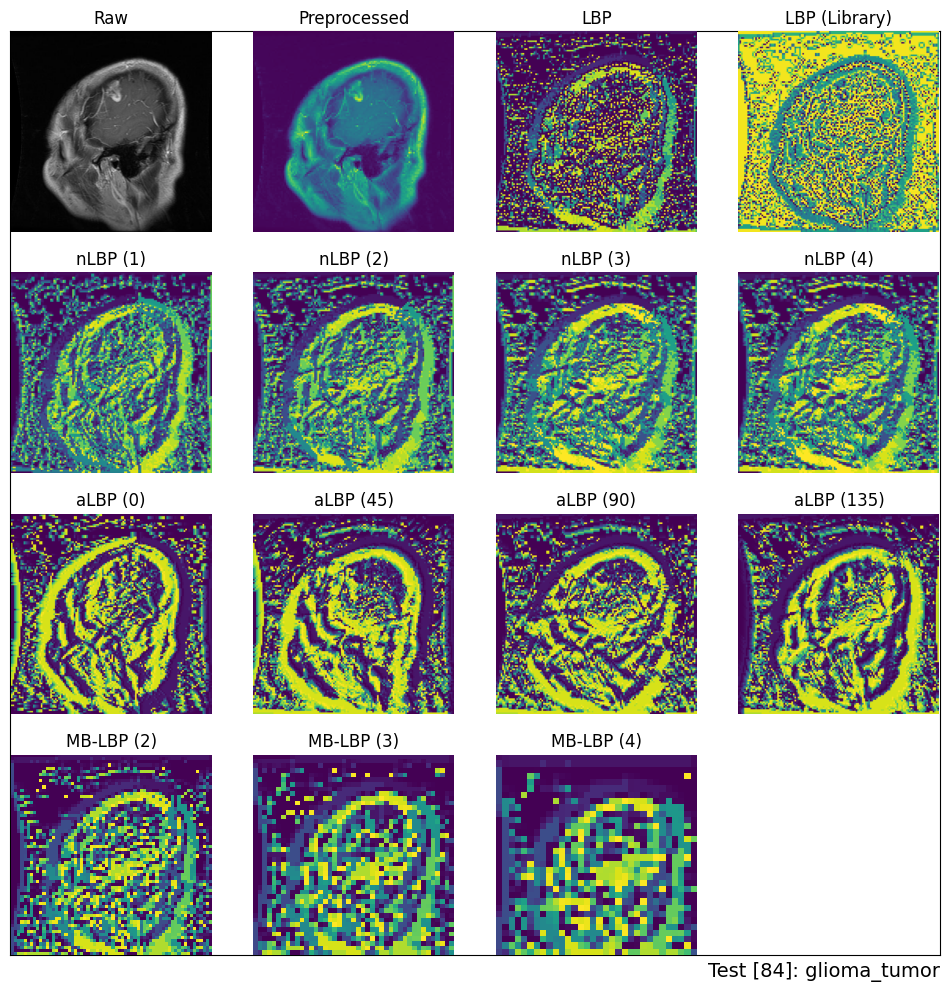

In [42]:
prvw_idx = 84

plt.figure(figsize=(12,12))
plt.xlabel(f"Test [{prvw_idx}]: {classes[y_test[prvw_idx]]}", fontsize=14, loc="right")
plt.yticks([])
plt.xticks([])

get_image_preview("Raw", X_test, 1)
get_image_preview("Preprocessed", X_test_prep, 2)
get_image_preview("LBP", X_test_lbp, 3)
get_image_preview("LBP (Library)", X_test_lbplib, 4)
get_image_preview("nLBP (1)", X_test_nlbp2, 5)
get_image_preview("nLBP (2)", X_test_nlbp3, 6)
get_image_preview("nLBP (3)", X_test_nlbp4, 7)
get_image_preview("nLBP (4)", X_test_nlbp4, 8)
get_image_preview("aLBP (0)", X_test_albp0, 9)
get_image_preview("aLBP (45)", X_test_albp45, 10)
get_image_preview("aLBP (90)", X_test_albp90, 11)
get_image_preview("aLBP (135)", X_test_albp135, 12)
get_image_preview("MB-LBP (2)", X_test_mblbp2, 13)
get_image_preview("MB-LBP (3)", X_test_mblbp3, 14)
get_image_preview("MB-LBP (4)", X_test_mblbp4, 15)
# get_image("SEMB-LBP (2)", X_test_semblbp2, 17)
# get_image("SEMB-LBP (3)", X_test_semblbp3, 18)
# get_image("SEMB-LBP (4)", X_test_semblbp4, 19)

plt.show()

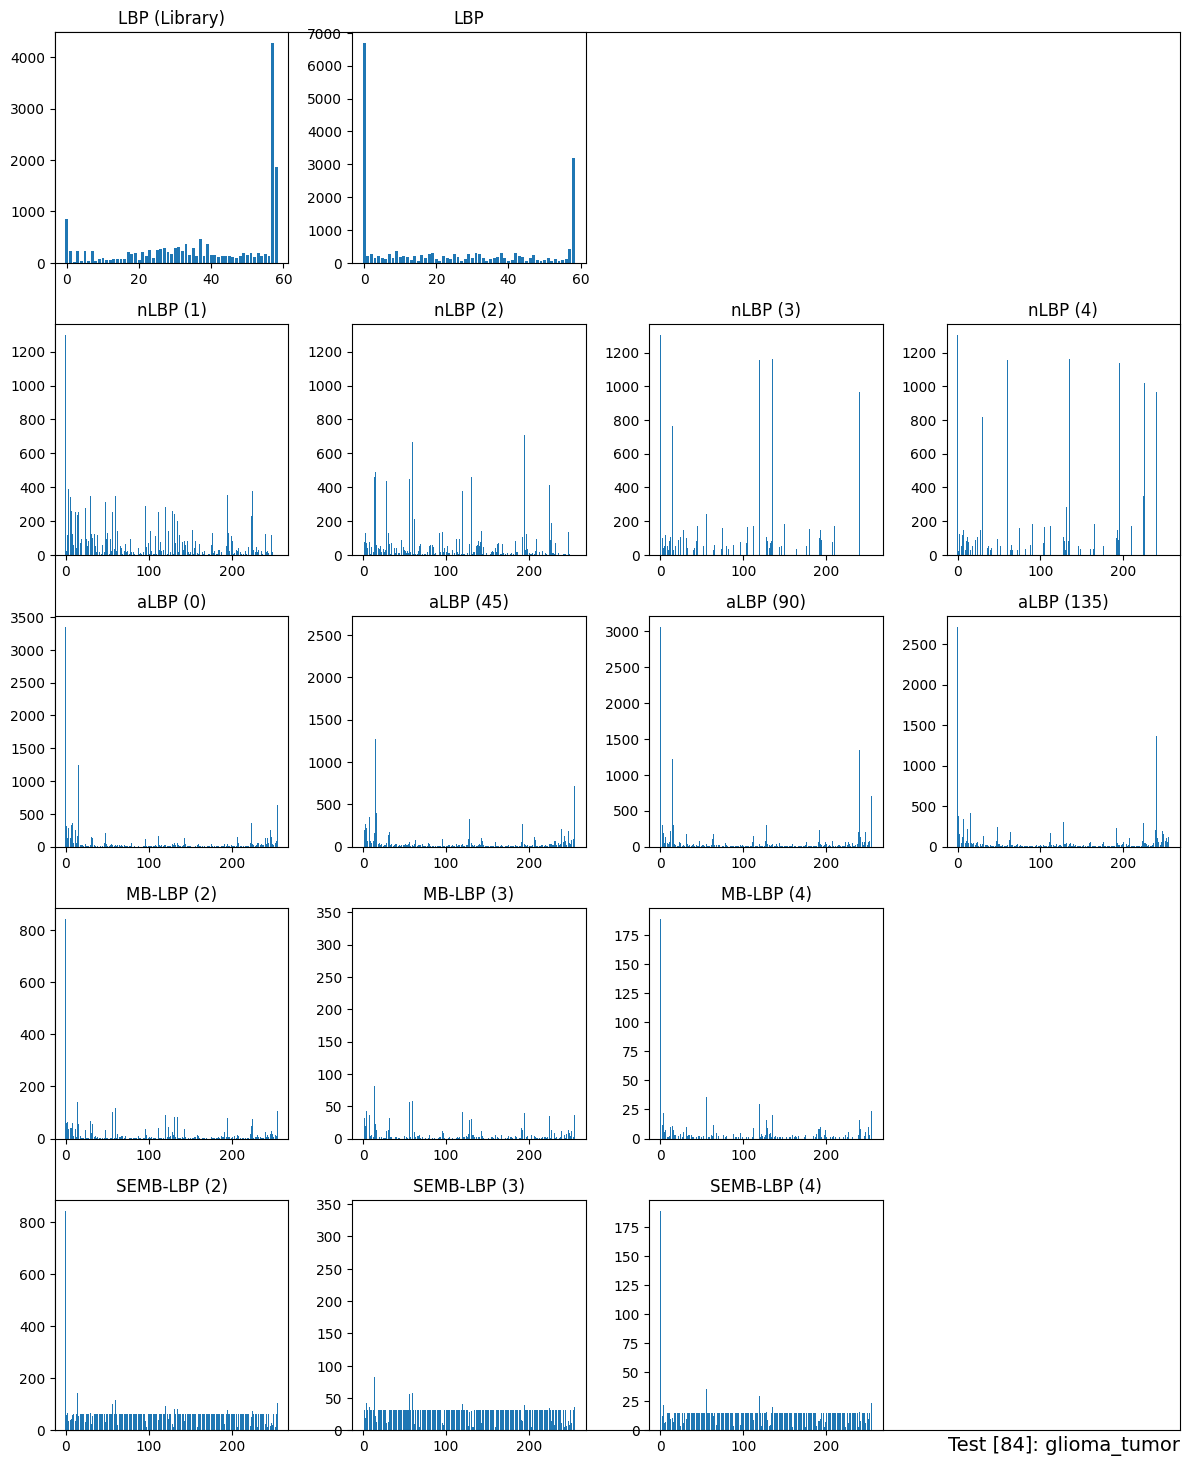

In [43]:
plt.figure(figsize=(12,15))
plt.xlabel(f"Test [{prvw_idx}]: {classes[y_test[prvw_idx]]}", fontsize=14, loc="right")
plt.yticks([])
plt.xticks([])

# get_histogram_preview("Raw", X_test, 1)
# get_histogram_preview("Preprocessed", X_test_prep, 2)
get_histogram_preview("LBP (Library)", X_test_lbplib_hist, 1)
get_histogram_preview("LBP", X_test_lbp_hist, 2)
get_histogram_preview("nLBP (1)", X_test_nlbp2_hist, 5)
get_histogram_preview("nLBP (2)", X_test_nlbp3_hist, 6)
get_histogram_preview("nLBP (3)", X_test_nlbp4_hist, 7)
get_histogram_preview("nLBP (4)", X_test_nlbp4_hist, 8)
get_histogram_preview("aLBP (0)", X_test_albp0_hist, 9)
get_histogram_preview("aLBP (45)", X_test_albp45_hist, 10)
get_histogram_preview("aLBP (90)", X_test_albp90_hist, 11)
get_histogram_preview("aLBP (135)", X_test_albp135_hist, 12)
get_histogram_preview("MB-LBP (2)", X_test_mblbp2_hist, 13)
get_histogram_preview("MB-LBP (3)", X_test_mblbp3_hist, 14)
get_histogram_preview("MB-LBP (4)", X_test_mblbp4_hist, 15)
get_histogram_preview("SEMB-LBP (2)", X_test_semblbp2_hist, 17)
get_histogram_preview("SEMB-LBP (3)", X_test_semblbp3_hist, 18)
get_histogram_preview("SEMB-LBP (4)", X_test_semblbp4_hist, 19)

plt.show()

#### Evaluation Process

--------------------------------- Best KNN | nlbp1 ---------------------------------


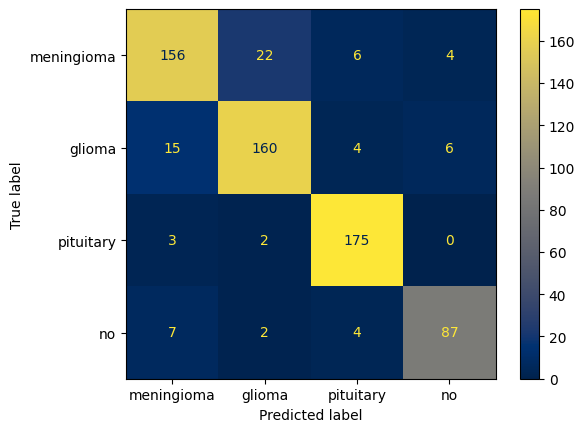

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
meningioma	0.9127105666156202  	0.861878453038674   	0.8297872340425532  	0.8455284552845529  
glioma    	0.9218989280245024  	0.8602150537634409  	0.8648648648648649  	0.8625336927223719  
pituitary 	0.9709035222052067  	0.9259259259259259  	0.9722222222222222  	0.948509485094851   
no        	0.9647779479326187  	0.8969072164948454  	0.87                	0.883248730964467   

> Global Performance
Accuracy (Micro) : 0.942572741194487
Accuracy (Macro) : 0.885145482388974
Precision        : 0.8862316623057216
Recall           : 0.8842185802824101
F1-Score         : 0.8849550910165607


In [92]:
knn_best_method = X_test_hists[FEATURES.index(knn_best["method"])]
knn_best_preds = knn_best["model"].predict(knn_best_method)
knn_best_eval = evaluate_model(knn_best_preds)
display_evaluation(f"Best KNN | {knn_best["method"]}", knn_best_eval)
# .94 .88

--------------------------------- Best DT | nlbp4 ---------------------------------


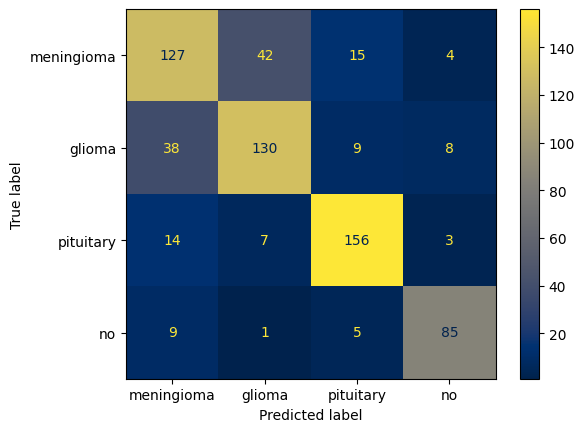

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
meningioma	0.8131699846860643  	0.675531914893617   	0.675531914893617   	0.675531914893617   
glioma    	0.8392036753445635  	0.7222222222222222  	0.7027027027027027  	0.7123287671232876  
pituitary 	0.9188361408882083  	0.8432432432432433  	0.8666666666666667  	0.8547945205479452  
no        	0.9540581929555896  	0.85                	0.85                	0.85                

> Global Performance
Accuracy (Micro) : 0.8813169984686064
Accuracy (Macro) : 0.7626339969372129
Precision        : 0.7727493450897706
Recall           : 0.7737253210657467
F1-Score         : 0.7731638006412125


In [91]:
dt_best_method = X_test_hists[FEATURES.index(dt_best["method"])]
dt_best_preds = dt_best["model"].predict(dt_best_method)
dt_best_eval = evaluate_model(dt_best_preds)
display_evaluation(f"Best DT | {dt_best["method"]}", dt_best_eval)
# .86 .74

In [93]:
rf_best_method = X_test_hists[FEATURES.index(rf_best["method"])]
rf_best_preds = rf_best["model"].predict(rf_best_method)
rf_best_eval = evaluate_model(rf_best_preds)
display_evaluation(f"Best RF | {rf_best["method"]}", rf_best_eval)
# .91 .82

NameError: name 'rf_best' is not defined

--------------------------------- Best MNB | lbp ---------------------------------


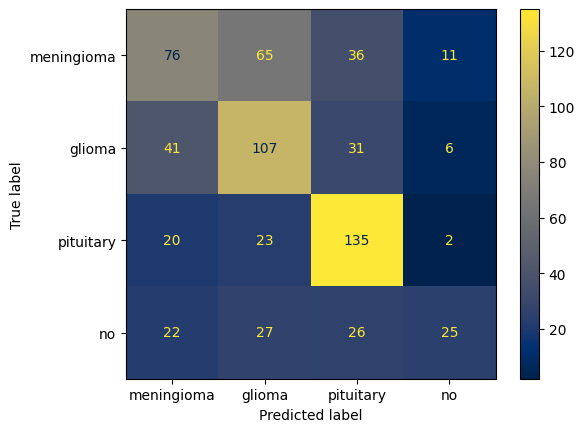

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
meningioma	0.7013782542113323  	0.4779874213836478  	0.40425531914893614 	0.4380403458213256  
glioma    	0.7044410413476263  	0.481981981981982   	0.5783783783783784  	0.5257985257985257  
pituitary 	0.7886676875957122  	0.5921052631578947  	0.75                	0.6617647058823529  
no        	0.8560490045941807  	0.5681818181818182  	0.25                	0.3472222222222222  

> Global Performance
Accuracy (Micro) : 0.7626339969372129
Accuracy (Macro) : 0.5252679938744257
Precision        : 0.5300641211763357
Recall           : 0.4956584243818286
F1-Score         : 0.4932064499311066


In [94]:
mnb_best_method = X_test_hists[FEATURES.index(mnb_best["method"])]
mnb_best_preds = mnb_best["model"].predict(mnb_best_method)
mnb_best_eval = evaluate_model(mnb_best_preds)
display_evaluation(f"Best MNB | {mnb_best["method"]}", mnb_best_eval)
# .76 .49

--------------------------------- Best GNB | lbp ---------------------------------


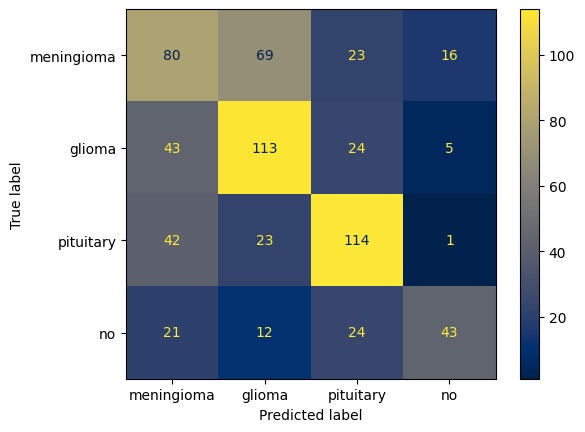

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
meningioma	0.6722817764165391  	0.43010752688172044 	0.425531914893617   	0.4278074866310161  
glioma    	0.7304747320061256  	0.5207373271889401  	0.6108108108108108  	0.5621890547263682  
pituitary 	0.7901990811638591  	0.6162162162162163  	0.6333333333333333  	0.6246575342465754  
no        	0.8790199081163859  	0.6615384615384615  	0.43                	0.5212121212121211  

> Global Performance
Accuracy (Micro) : 0.7679938744257273
Accuracy (Macro) : 0.5359877488514548
Precision        : 0.5571498829563345
Recall           : 0.5249190147594403
F1-Score         : 0.5339665492040202


In [95]:
gnb_best_method = X_test_hists[FEATURES.index(gnb_best["method"])]
gnb_best_preds = gnb_best["model"].predict(gnb_best_method)
gnb_best_eval = evaluate_model(gnb_best_preds)
display_evaluation(f"Best GNB | {gnb_best["method"]}", gnb_best_eval)
# .76 .53

--------------------------------- Best SVM - Linear Kernel (LinearSVC) | nlbp1 ---------------------------------


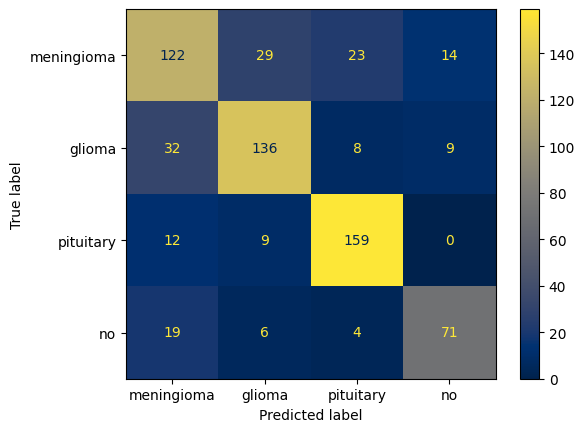

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
meningioma	0.8024502297090352  	0.6594594594594595  	0.648936170212766   	0.6541554959785523  
glioma    	0.8575803981623277  	0.7555555555555555  	0.7351351351351352  	0.7452054794520548  
pituitary 	0.9142419601837672  	0.8195876288659794  	0.8833333333333333  	0.8502673796791443  
no        	0.9203675344563553  	0.7553191489361702  	0.71                	0.731958762886598   

> Global Performance
Accuracy (Micro) : 0.8736600306278713
Accuracy (Macro) : 0.7473200612557427
Precision        : 0.7474804482042912
Recall           : 0.7443511596703086
F1-Score         : 0.7453967794990873


In [96]:
svm_linearlib_best_method = X_test_hists[FEATURES.index(svm_linearlib_best["method"])]
svm_linearlib_best_preds = svm_linearlib_best["model"].predict(svm_linearlib_best_method)
svm_linearlib_best_eval = evaluate_model(svm_linearlib_best_preds)
display_evaluation(f"Best SVM - Linear Kernel (LinearSVC) | {svm_linearlib_best["method"]}", svm_linearlib_best_eval)
# .87 .74

--------------------------------- Best SVM - Linear Kernel (SVC Library) | nlbp1 ---------------------------------


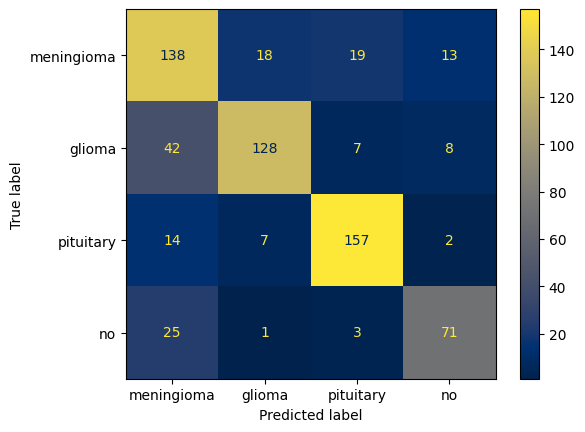

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
meningioma	0.7993874425727412  	0.6301369863013698  	0.7340425531914894  	0.6781326781326781  
glioma    	0.8728943338437979  	0.8311688311688312  	0.6918918918918919  	0.7551622418879056  
pituitary 	0.9203675344563553  	0.8440860215053764  	0.8722222222222222  	0.8579234972677596  
no        	0.9203675344563553  	0.7553191489361702  	0.71                	0.731958762886598   

> Global Performance
Accuracy (Micro) : 0.8782542113323124
Accuracy (Macro) : 0.7565084226646248
Precision        : 0.765177746977937
Recall           : 0.7520391668264008
F1-Score         : 0.7557942950437353


In [97]:
svm_linear_best_method = X_test_hists[FEATURES.index(svm_linear_best["method"])]
svm_linear_best_preds = svm_linear_best["model"].predict(svm_linear_best_method)
svm_linear_best_eval = evaluate_model(svm_linear_best_preds)
display_evaluation(f"Best SVM - Linear Kernel (SVC Library) | {svm_linear_best["method"]}", svm_linear_best_eval)
# .87 .75

--------------------------------- Best SVM - Polynomial Kernel | nlbp1 ---------------------------------


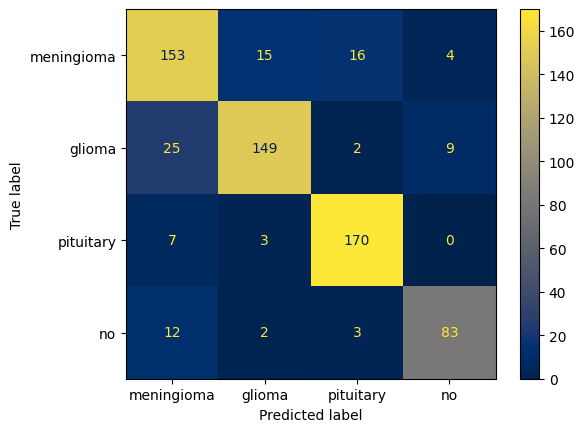

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
meningioma	0.8790199081163859  	0.7766497461928934  	0.8138297872340425  	0.7948051948051947  
glioma    	0.9142419601837672  	0.8816568047337278  	0.8054054054054054  	0.8418079096045197  
pituitary 	0.9525267993874426  	0.8900523560209425  	0.9444444444444444  	0.9164420485175202  
no        	0.9540581929555896  	0.8645833333333334  	0.83                	0.8469387755102041  

> Global Performance
Accuracy (Micro) : 0.9249617151607963
Accuracy (Macro) : 0.8499234303215927
Precision        : 0.8532355600702243
Recall           : 0.8484199092709731
F1-Score         : 0.8499984821093597


In [98]:
svm_polynomial_best_method = X_test_hists[FEATURES.index(svm_polynomial_best["method"])]
svm_polynomial_best_preds = svm_polynomial_best["model"].predict(svm_polynomial_best_method)
svm_polynomial_best_eval = evaluate_model(svm_polynomial_best_preds)
display_evaluation(f"Best SVM - Polynomial Kernel | {svm_polynomial_best["method"]}", svm_polynomial_best_eval)
# .92 .84

--------------------------------- Best SVM - Sigmoid Kernel | nlbp4 ---------------------------------


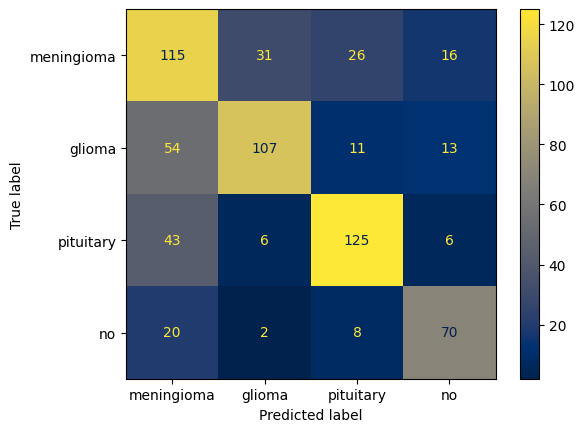

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
meningioma	0.7090352220520674  	0.4956896551724138  	0.6117021276595744  	0.5476190476190476  
glioma    	0.8208269525267994  	0.7328767123287672  	0.5783783783783784  	0.6465256797583082  
pituitary 	0.8468606431852986  	0.7352941176470589  	0.6944444444444444  	0.7142857142857144  
no        	0.900459418070444   	0.6666666666666666  	0.7                 	0.6829268292682926  

> Global Performance
Accuracy (Micro) : 0.8192955589586524
Accuracy (Macro) : 0.6385911179173047
Precision        : 0.6576317879537266
Recall           : 0.6461312376205993
F1-Score         : 0.6478393177328408


In [99]:
svm_sigmoid_best_method = X_test_hists[FEATURES.index(svm_sigmoid_best["method"])]
svm_sigmoid_best_preds = svm_sigmoid_best["model"].predict(svm_sigmoid_best_method)
svm_sigmoid_best_eval = evaluate_model(svm_sigmoid_best_preds)
display_evaluation(f"Best SVM - Sigmoid Kernel | {svm_sigmoid_best["method"]}", svm_sigmoid_best_eval)
# .81 .64

--------------------------------- Best SVM - RBF Kernel | lbp ---------------------------------


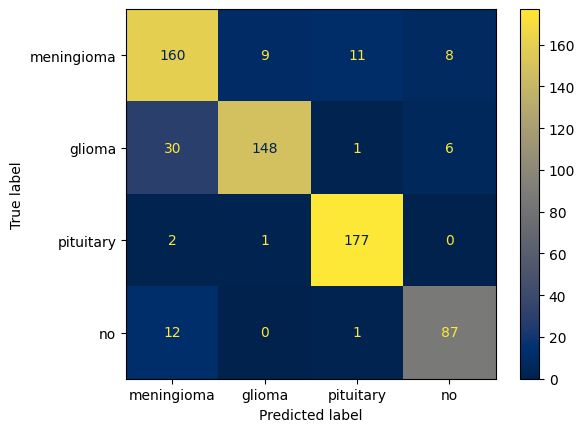

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
meningioma	0.889739663093415   	0.7843137254901961  	0.851063829787234   	0.8163265306122448  
glioma    	0.9280245022970903  	0.9367088607594937  	0.8                 	0.8629737609329446  
pituitary 	0.9754977029096478  	0.9315789473684211  	0.9833333333333333  	0.9567567567567566  
no        	0.9586523736600306  	0.8613861386138614  	0.87                	0.8656716417910448  

> Global Performance
Accuracy (Micro) : 0.9379785604900459
Accuracy (Macro) : 0.8759571209800919
Precision        : 0.878496918057993
Recall           : 0.8760992907801419
F1-Score         : 0.8754321725232477


In [100]:
svm_rbf_best_method = X_test_hists[FEATURES.index(svm_rbf_best["method"])]
svm_rbf_best_preds = svm_rbf_best["model"].predict(svm_rbf_best_method)
svm_rbf_best_eval = evaluate_model(svm_rbf_best_preds)
display_evaluation(f"Best SVM - RBF Kernel | {svm_rbf_best["method"]}", svm_rbf_best_eval)
# .93 .87

## Deep Learning

#### DL - Preprocessing

In [ ]:
# Data preprocessing function for deep learning classifiers
def preprocess_dl(images):
    preprocessed = []

    for img in images:
        # Resize image into same size
        img_resized = cv.resize(img, (CNN_IMAGE_SIZE, CNN_IMAGE_SIZE))

        # Convert image from BGR (default configuration of MRI image dataset) 
        # to RGB (preferred image channel for CNN model)
        img_rgb = cv.cvtColor(img_resized, cv.COLOR_BGR2RGB)

        # Normailze image pixel intensity values
        img_norm = img_rgb / 255

        preprocessed.append(img_norm)
    
    return preprocessed

In [35]:
# Preprocess dataset for deep learning classifier using the same data as machine learning classifiers
X_train_cnn = np.array(preprocess_dl(X_train))
y_train_cnn = np.array(y_train.copy())

X_test_cnn = np.array(preprocess_dl(X_test))
y_test_cnn = np.array(y_test.copy())

print("X_train_cnn\ty_train_cnn\t")
print(f"{len(X_train_cnn)}\t\t{len(y_train_cnn)}\n")
print("X_test_cnn\ty_test_cnn\t")
print(f"{len(X_test_cnn)}\t\t{len(y_test_cnn)}\t")

X_train_cnn	y_train_cnn	
2611		2611

X_test_cnn	y_test_cnn	
653		653	


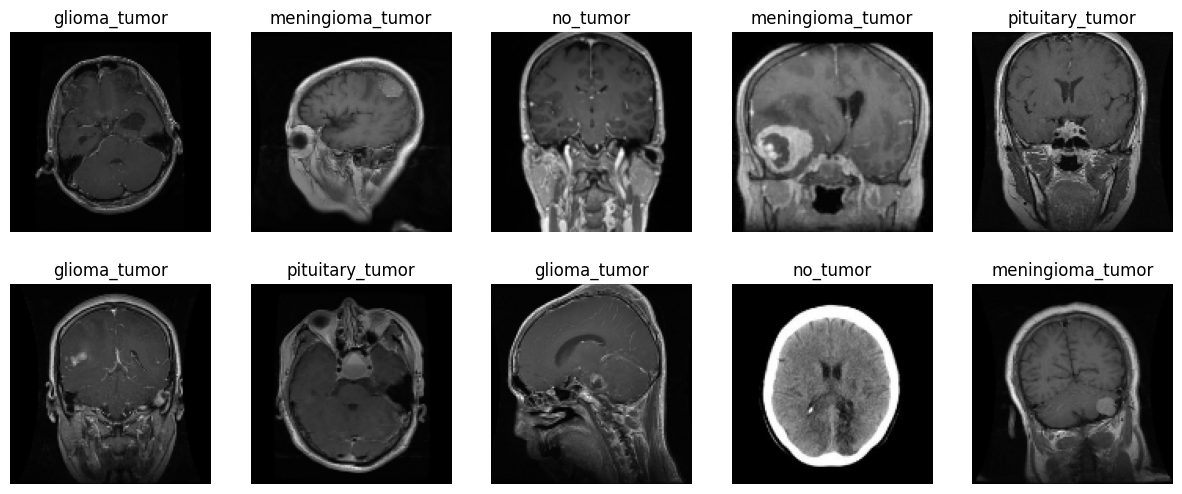

In [36]:
# Display training sample images
plt.figure(figsize=(15,6))
for i in range(1,11):
    plt.subplot(2,5,i)
    plt.axis("off")
    plt.title(classes[y_train_cnn[i]])
    plt.imshow(X_train_cnn[i])
plt.show()

### DL - Modelling

In [37]:
cnn_model = keras.Sequential([
    layers.Input(shape=(CNN_IMAGE_SIZE, CNN_IMAGE_SIZE, 3)), 
    
    # layers.RandomFlip(),
    # layers.RandomRotation(factor=.2),

    layers.Conv2D(filters=32, kernel_size=(3,3), 
                  activation='relu', padding='same'),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(filters=64, kernel_size=(3,3),
                  activation='relu', padding='same'),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(filters=128, kernel_size=(3,3),
                  activation='relu', padding='same'),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(filters=256, kernel_size=(3,3),
                  activation='relu', padding='same'),
    layers.MaxPool2D((2,2)),

    layers.Flatten(),
    
    layers.Dense(units=512, activation='relu'),
    layers.Dropout(rate=0.5), # Overfit handling
    layers.Dense(units=256, activation='relu'),
    layers.Dropout(rate=0.35),
    layers.Dense(units=128, activation='relu'),
    layers.Dropout(rate=0.2),
    layers.Dense(units=4, activation='softmax')
])

cnn_model.summary()

E0000 00:00:1776501410.734361    6178 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776501410.743861    6178 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,942,276 (34.11 MB)

 Trainable params: 8,942,276 (34.11 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Set CNN model parameters
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=[keras.metrics.sparse_categorical_accuracy]
)

cnn_model.get_compile_config()

{'optimizer': {'module': 'keras.optimizers',
  'class_name': 'Adam',
  'config': {'name': 'adam',
   'learning_rate': 0.0010000000474974513,
   'weight_decay': None,
   'clipnorm': None,
   'global_clipnorm': None,
   'clipvalue': None,
   'use_ema': False,
   'ema_momentum': 0.99,
   'ema_overwrite_frequency': None,
   'loss_scale_factor': None,
   'gradient_accumulation_steps': None,
   'beta_1': 0.9,
   'beta_2': 0.999,
   'epsilon': 1e-07,
   'amsgrad': False},
  'registered_name': None},
 'loss': 'sparse_categorical_crossentropy',
 'loss_weights': None,
 'metrics': [{'module': 'builtins',
   'class_name': 'function',
   'config': 'sparse_categorical_accuracy',
   'registered_name': 'function'}],
 'weighted_metrics': None,
 'run_eagerly': False,
 'steps_per_execution': 1,
 'jit_compile': False}

In [39]:
cnn_start = time.perf_counter()

# Early stopping to handle overfit
cnn_early_stopping = EarlyStopping(monitor="val_loss",
                                   patience=5,
                                   restore_best_weights=True)

# Train and validate CNN model
cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train_cnn,
    epochs=50,
    batch_size=16,
    validation_split=0.2,   
    callbacks=[cnn_early_stopping]
)

print(f"\nCNN Model Built in {time.perf_counter() - cnn_start}s")

# .01 .99 .76 .90 best train
# .18 .94 .34 .88 best val - 4 layer blocks

Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - loss: 1.2676 - sparse_categorical_accuracy: 0.3894 - val_loss: 1.1054 - val_sparse_categorical_accuracy: 0.4876
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - loss: 0.9707 - sparse_categorical_accuracy: 0.5632 - val_loss: 0.8600 - val_sparse_categorical_accuracy: 0.6176
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - loss: 0.7805 - sparse_categorical_accuracy: 0.6571 - val_loss: 0.7079 - val_sparse_categorical_accuracy: 0.7247
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - loss: 0.6340 - sparse_categorical_accuracy: 0.7414 - val_loss: 0.5478 - val_sparse_categorical_accuracy: 0.7973
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 13s 99ms/step - loss: 0.5030 - sparse_categorical_accuracy: 0.8022 - val_loss: 0.5587 - val_sparse_categorical_accuracy: 0.7954
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 13s 99ms/step - loss: 0.4408 - sparse_categorical_accuracy: 0.8333 - val_loss: 0.4927 - val_sparse_categorical_accuracy:

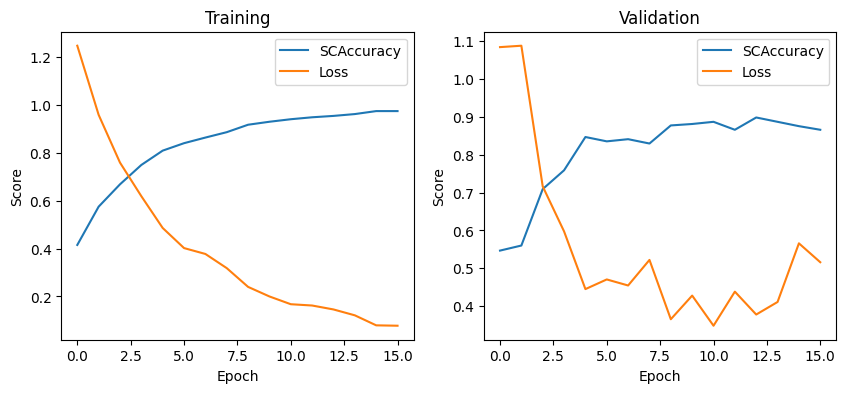

In [139]:
plt.figure(figsize=(10,4))

# Plot training set performance score graph
plt.subplot(1,2,1)
plt.title("Training")
plt.plot(cnn_history.history["sparse_categorical_accuracy"])
plt.plot(cnn_history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend(["SCAccuracy", "Loss"])

# Plot validation set performance score graph
plt.subplot(1,2,2)
plt.title("Validation")
plt.plot(cnn_history.history["val_sparse_categorical_accuracy"])
plt.plot(cnn_history.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend(["SCAccuracy", "Loss"])

plt.show()

In [140]:
# Test model predictions
cnn_pred = cnn_model.predict(X_test_cnn)
cnn_pred_classes = np.argmax(cnn_pred, axis=1)

# Count model classification performance on test set
true, false = 0, 0
for i in range(len(cnn_pred_classes)):
    if(cnn_pred_classes[i] == y_test_cnn[i]): true += 1 
    else: false += 1

print("True:", true, "False:", false)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
True: 570 False: 83


### DL - Evaluation

In [141]:
# Test CNN model performance with unseen test data
cnn_loss, cnn_accuracy = cnn_model.evaluate(
    X_test_cnn,
    y_test_cnn,
)

print("Accuracy >", cnn_accuracy)
print("Loss     >", cnn_loss)
# .871 .378

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.3508 - sparse_categorical_accuracy: 0.8729
Accuracy > 0.8728943467140198
Loss     > 0.3507709205150604


## Explainable AI - LIME

### XAI: Best Model

#### SVM + Kernel

In [109]:
svm_best_kernels = ["Linear (Lib)", "Linear (SVC)", "Polynomial", "Sigmoid", "RBF"]
svm_best_models = [svm_linearlib_best, svm_linear_best, svm_polynomial_best, svm_sigmoid_best, svm_rbf_best]
svm_best_evals = [svm_linearlib_best_eval, svm_linear_best_eval, svm_polynomial_best_eval, svm_sigmoid_best_eval, svm_rbf_best_eval]

svm_best_sorted = [x for _, x in sorted(zip(svm_best_evals, svm_best_models), key=lambda x:x[0]["global"]["f1-score"], reverse=True)]
svm_best = svm_best_sorted[0]

print("Kernel\t", "LBP Var", "F1-Score\t", "Accuracy", sep="\t\t")
for i in range(len(svm_best_evals)):
    print(str(svm_best_kernels[i]).ljust(12), svm_best_models[i]["method"], svm_best_evals[i]["global"]["f1-score"], svm_best_evals[i]["global"]["accuracy"], sep="\t\t")

print(f"\n> Best SVM Model")
print("Pipeline:", svm_best["model"].best_estimator_.named_steps)
print("Kernel\t:", svm_best["model"].best_params_["classifier__kernel"])
print("Method\t:", svm_best["method"])
print("CV Time\t:", svm_best["time"])

Kernel			LBP Var		F1-Score			Accuracy
Linear (Lib)		nlbp1		0.7453967794990873		0.8736600306278713
Linear (SVC)		nlbp1		0.7557942950437353		0.8782542113323124
Polynomial  		nlbp1		0.8499984821093597		0.9249617151607963
Sigmoid     		nlbp4		0.6478393177328408		0.8192955589586524
RBF         		lbp		0.8754321725232477		0.9379785604900459

> Best SVM Model
Pipeline: {'scaler': StandardScaler(), 'classifier': SVC(C=10, decision_function_shape='ovo', gamma=0.1, random_state=42)}
Kernel	: rbf
Method	: lbp
CV Time	: 2.888205106999976


#### Retrain with Probability

<BarContainer object of 59 artists>

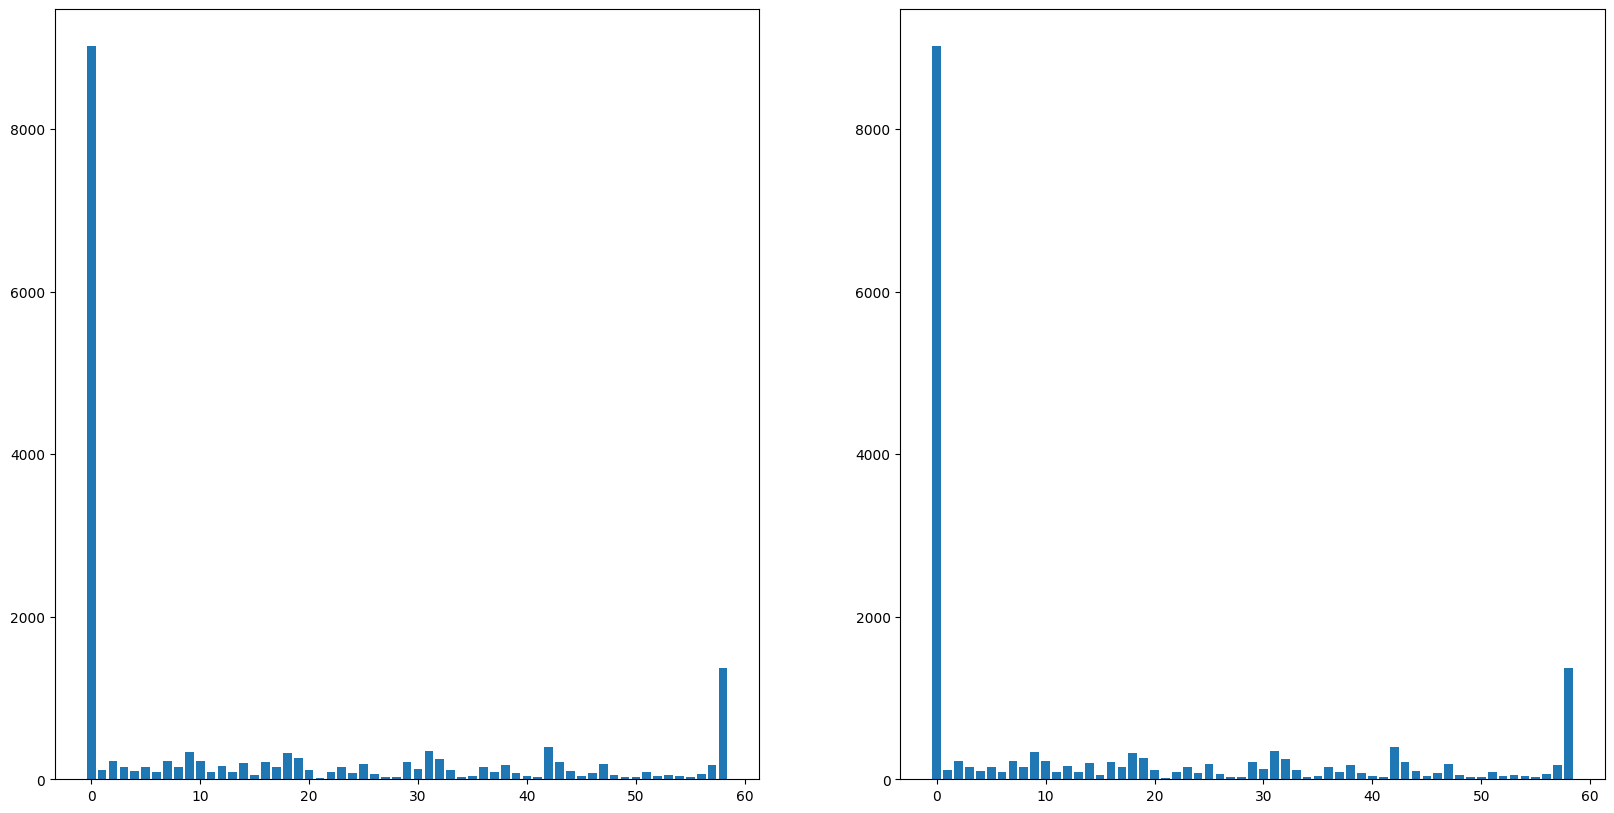

In [82]:
best_hist = X_train_hists[FEATURES.index(svm_best["method"])]

plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
plt.bar(np.arange(len(best_hist[0])), best_hist[0])
plt.subplot(1,2,2)
plt.bar(np.arange(len(X_train_lbp_hist[0])), X_train_lbp_hist[0])

In [ ]:
svm_rbf_prob_time_start = time.perf_counter()

# Convert SVM best params set values into list type for cross validation step 
svm_best_params = svm_best["model"].best_params_
svm_new_params = {
    "classifier__kernel": [svm_best_params["classifier__kernel"]],
    "classifier__C": [svm_best_params["classifier__C"]],
    "classifier__gamma": [svm_best_params["classifier__gamma"]],
    "classifier__decision_function_shape": [svm_best_params["classifier__decision_function_shape"]],
}

# Get the relevant histogram based on the best method
svm_best_feature = X_train_hists[FEATURES.index(svm_best["method"])]

svm_rbf_prob_title = "(Scaled) Support Vector Machine - RBF Kernel (Probability)"
svm_rbf_prob_base_model = SVC(probability=True, random_state=42)
svm_rbf_prob_param_grid = svm_new_params

print("   Method\tScore\t\tTime\t\tParameters")
svm_rbf_prob_best = get_model(0, svm_best["method"], svm_rbf_prob_base_model, svm_new_params, svm_best_feature, scale=True)

print(f"\nCompleted in {time.perf_counter() - svm_rbf_prob_time_start}s")
# .870 2.44

   Method	Score		Time		Parameters
0  lbp  	0.870729	3.157749s 	{'classifier__C': 10, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 0.1, 'classifier__kernel': 'rbf'}

Completed in 3.158350887999404s


#### Evaluate Probability SVM

--------------------------------- Best SVM - RBF Kernel | lbp ---------------------------------


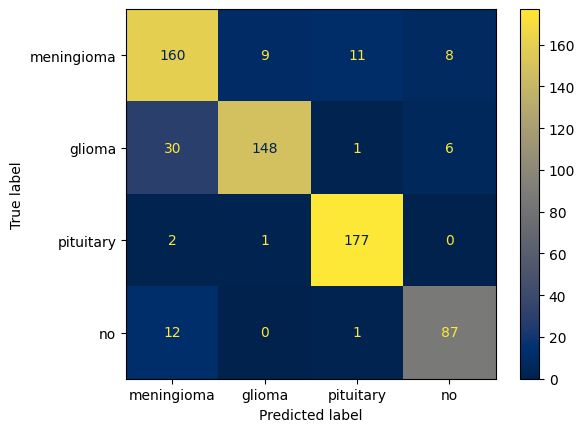

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
meningioma	0.889739663093415   	0.7843137254901961  	0.851063829787234   	0.8163265306122448  
glioma    	0.9280245022970903  	0.9367088607594937  	0.8                 	0.8629737609329446  
pituitary 	0.9754977029096478  	0.9315789473684211  	0.9833333333333333  	0.9567567567567566  
no        	0.9586523736600306  	0.8613861386138614  	0.87                	0.8656716417910448  

> Global Performance
Accuracy (Micro) : 0.9379785604900459
Accuracy (Macro) : 0.8759571209800919
Precision        : 0.878496918057993
Recall           : 0.8760992907801419
F1-Score         : 0.8754321725232477


In [121]:
svm_rbf_prob_best_method = X_test_hists[FEATURES.index(svm_rbf_prob_best["method"])]
svm_rbf_prob_best_preds = svm_rbf_prob_best["model"].predict(svm_rbf_prob_best_method)
svm_rbf_prob_best_eval = evaluate_model(svm_rbf_prob_best_preds)
display_evaluation(f"Best SVM - RBF Kernel | {svm_rbf_prob_best["method"]}", svm_rbf_prob_best_eval)
# .93 .87

### XAI: Train LIME Explanation

In [122]:
def svm_classifier_fn(images):
    features = []
    for img in images:
        img_resized = cv.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
        img_grayscaled = cv.cvtColor(img_resized, cv.COLOR_BGR2GRAY)
        _, hist_lbp = get_feature_histogram(img_grayscaled, svm_rbf_prob_best["method"]) 
        # _, hist_lbp = get_lbp(img_grayscaled) 
        features.append(hist_lbp)

    svm_pred = svm_rbf_prob_best["model"].predict_proba(np.array(features))
    return svm_pred

In [139]:
sample_idxs = [30, 31, 32, 33]
explanations = []

explainer = lime_image.LimeImageExplainer()

for idx in sample_idxs:
    explanation = explainer.explain_instance(X_test[idx],
                                             svm_classifier_fn,
                                             # labels=[0,1,2,3],
                                             # top_labels=4,
                                             hide_color=0,
                                             # batch_size=32,
                                             random_seed=42,
                                             num_samples=1000)
    explanations.append(explanation)

100%|██████████| 1000/1000 [00:39<00:00, 25.40it/s]


### XAI: LIME Explanation Visualization

30 > Pred: pituitary_tumor | True: meningioma_tumor
31 > Pred: no_tumor | True: meningioma_tumor
32 > Pred: meningioma_tumor | True: meningioma_tumor
33 > Pred: glioma_tumor | True: meningioma_tumor


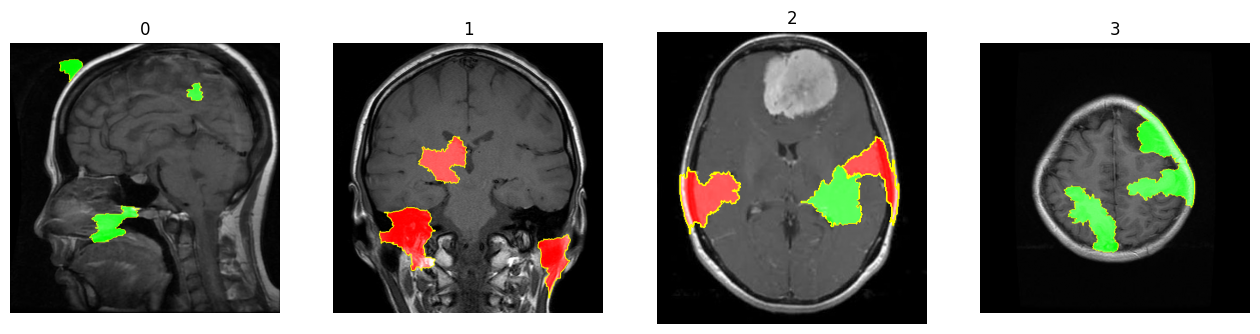

In [125]:
plt.figure(figsize=(16,4))
for i, exp in enumerate(explanations):
    pred = exp.top_labels[0]
    temp, mask = exp.get_image_and_mask(pred,
                                        positive_only=False,
                                        num_features=3,
                                        hide_rest=False)
    print(sample_idxs[i], "> Pred:", classes[pred], "| True:", classes[y[sample_idxs[i]]])
    plt.subplot(1, len(explanations), i+1)
    plt.imshow(mark_boundaries(temp, mask))
    plt.axis("off")
    plt.title(i)

plt.show()

## Save Model

In [132]:
directory = "./output/"
svm_filename = "best_svm.pkl"
lime_filename = "lime_explanations.pkl"

if(not os.path.exists(directory)): os.mkdir(directory)

In [ ]:
# Save best trained SVM model
pickle.dump(svm_rbf_prob_best, open(f"{directory}{svm_filename}", "wb"))

In [ ]:
# Save trained LIME explanations
pickle.dump(explanations, open(f"{directory}{lime_filename}", "wb"))